# FCN for Time Series Classification — Experiments 3.0
## 2× Width Scaling Study (Wang, Yan & Oates, 2016)

---

### Areas for improvment in the original FCN reproduction

| # | Issue | Fix |
|---|-------|-----|
| 1 | **Conv2D on (T,1,1)** — paper describes 1D convolutions | Rewrite with Conv1D |
| 2 | Code duplicated per dataset | Modular pipeline |
| 3 | Float batch_size, fragile label encoding | Integer `//`, LabelEncoder |
| 4 | Only `np.random.seed` | Seed all RNGs |
| 5 | No early stopping; min training loss selection | Early stopping on `val_loss` |
| 6 | `ReduceLROnPlateau` monitors training loss | Monitor `val_loss` |
| 7 | FCN has **zero regularisation** (no dropout, no L2) | SpatialDropout + L2 |
| 8 | Single fixed kernel size per layer | Multi-scale parallel branches |
| **3.0** | **2.0 filter widths** | **All filter counts doubled (128→256, 256→512)** |
| 9 | CAM code uses deprecated `K.learning_phase()` | Rewrite with `tf.GradientTape` |
| 10 | No attention mechanism | Squeeze-and-Excitation blocks |

### Dataset-Specific Improvement Rationale

| Dataset | Key Challenge | Targeted Improvements |
|---------|--------------|----------------------|
| **Adiac** (37 cls, 176 len, 390 train) | Many classes, subtle inter-class differences | SE attention helps discriminate fine-grained patterns; label smoothing prevents overconfidence across 37 classes |
| **GunPoint** (2 cls, 150 len, 50 train) | Very small training set | Mixup + jitter create virtual samples; simple architecture suffices |
| **Coffee** (2 cls, 286 len, 28 train) | Extremely small (28 samples!) | Augmentation is critical; dropout prevents memorisation |
| **InlineSkate** (7 cls, 1882 len, 100 train) | Very long series, small train | Multi-scale kernels capture both local/global patterns; gradient clipping prevents exploding gradients on long sequences |
| **MedicalImages** (10 cls, 99 len, 381 train) | Severe imbalance (6 vs 203 per class) | Class weighting essential; short series means smaller kernels matter more |

In [ ]:
pip install aeon

In [2]:
import os
import random
import warnings
import time
import logging
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
logging.getLogger('tensorflow').setLevel(logging.ERROR)

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detected       : {[g.name for g in gpus]}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    try:
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision    : enabled (float16)")
    except Exception:
        print("Mixed precision    : not available")
else:
    print("GPU detected       : None (using CPU)")

TensorFlow version : 2.21.0
NumPy version      : 2.2.6
GPU detected       : ['/physical_device:GPU:0']
Mixed precision    : enabled (float16)


In [3]:
def set_all_seeds(seed: int = 813306) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['PYTHONHASHSEED'] = str(seed)

set_all_seeds(813306)

### Centralised Configuration

In [4]:
CONFIG = {
    'datasets': [
        'Adiac', 'GunPoint', 'Coffee', 'InlineSkate', 'MedicalImages',
    ],
    'nb_epochs': 2000,  # Paper uses 2000 for FCN
    'batch_size_divisor': 10,
    'max_batch_size': 16,

    'adam_lr': 0.001,
    'adam_beta1': 0.9,
    'adam_beta2': 0.999,
    'adam_epsilon': 1e-8,

    'reduce_lr_monitor': 'val_loss',
    'reduce_lr_factor': 0.5,
    'reduce_lr_patience': 50,
    'reduce_lr_min_lr': 1e-4,

    'use_cosine_annealing': False,

    'seeds': [315, 7543, 813306],
    'jitter_sigma': 0.03,
    'output_dir': 'results_3_0',
}

PAPER_FCN_ERRORS = {
    'Adiac': 0.143, 'GunPoint': 0.0, 'Coffee': 0.0,
    'InlineSkate': 0.589, 'MedicalImages': 0.208,
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)
print("Configuration loaded:")
for k, v in CONFIG.items():
    if k != 'output_dir':
        print(f"  {k:30s} = {v}")

Configuration loaded:
  datasets                       = ['Adiac', 'GunPoint', 'Coffee', 'InlineSkate', 'MedicalImages']
  nb_epochs                      = 2000
  batch_size_divisor             = 10
  max_batch_size                 = 16
  adam_lr                        = 0.001
  adam_beta1                     = 0.9
  adam_beta2                     = 0.999
  adam_epsilon                   = 1e-08
  reduce_lr_monitor              = val_loss
  reduce_lr_factor               = 0.5
  reduce_lr_patience             = 50
  reduce_lr_min_lr               = 0.0001
  use_cosine_annealing           = False
  seeds                          = [315, 7543, 813306]
  jitter_sigma                   = 0.03


### Data Loading & Preprocessing

In [5]:
def load_ucr_dataset(name: str):
    try:
        from aeon.datasets import load_classification
        x_tr, y_tr = load_classification(name, split='train')
        x_te, y_te = load_classification(name, split='test')
        if x_tr.ndim == 3 and x_tr.shape[1] == 1:
            x_tr = x_tr.squeeze(axis=1)
            x_te = x_te.squeeze(axis=1)
        le = LabelEncoder()
        y_tr = le.fit_transform(y_tr).astype(np.int32)
        y_te = le.transform(y_te).astype(np.int32)
        print(f"    [aeon] Loaded '{name}'")
        return x_tr, y_tr, x_te, y_te
    except Exception as e:
        print(f"    [aeon] not available ({e}); trying local files...")
    for ext in ['', '.txt', '.tsv']:
        trn = os.path.join(name, f'{name}_TRAIN{ext}')
        tst = os.path.join(name, f'{name}_TEST{ext}')
        if os.path.exists(trn) and os.path.exists(tst):
            d_tr = np.loadtxt(trn, delimiter=',')
            d_te = np.loadtxt(tst, delimiter=',')
            x_tr, y_raw_tr = d_tr[:, 1:], d_tr[:, 0]
            x_te, y_raw_te = d_te[:, 1:], d_te[:, 0]
            le = LabelEncoder()
            y_tr = le.fit_transform(y_raw_tr).astype(np.int32)
            y_te = le.transform(y_raw_te).astype(np.int32)
            print(f"    [local] Loaded '{name}' from {trn}")
            return x_tr, y_tr, x_te, y_te
    raise FileNotFoundError(f"Cannot find '{name}'.")


def z_normalise(x_train, x_test, per_feature=False):
    if per_feature:
        mean = x_train.mean(axis=0, keepdims=True)
        std  = x_train.std(axis=0, keepdims=True)
    else:
        mean = x_train.mean()
        std  = x_train.std()
    std = np.where(std == 0, 1.0, std)
    return (np.nan_to_num((x_train - mean) / std, nan=0.0),
            np.nan_to_num((x_test  - mean) / std, nan=0.0))


def augment_jitter(x, sigma=0.03, seed=None):
    rng = np.random.RandomState(seed) if seed else np.random
    return x + rng.normal(0, sigma, x.shape)


def augment_scaling(x, sigma=0.1, seed=None):
    rng = np.random.RandomState(seed) if seed else np.random
    return x * rng.normal(1.0, sigma, size=(x.shape[0], 1))


def augment_window_warp(x, window_ratio=0.1, scales=(0.5, 2.0), seed=None):
    """IMPROVEMENT: Window warping — randomly speed up or slow down
    a subsequence. Teaches temporal invariance, especially useful
    for InlineSkate where gesture speed varies between subjects."""
    rng = np.random.RandomState(seed) if seed else np.random
    x_new = x.copy()
    T = x.shape[1] if x.ndim >= 2 else x.shape[0]
    warp_len = max(1, int(T * window_ratio))
    for i in range(x_new.shape[0]):
        start = rng.randint(0, T - warp_len)
        scale = rng.uniform(scales[0], scales[1])
        window = x_new[i, start:start+warp_len]
        new_len = max(1, int(warp_len * scale))
        warped = np.interp(
            np.linspace(0, len(window)-1, new_len),
            np.arange(len(window)), window
        )
        left = x_new[i, :start]
        right = x_new[i, start+warp_len:]
        combined = np.concatenate([left, warped, right])
        x_new[i] = np.interp(
            np.linspace(0, len(combined)-1, T),
            np.arange(len(combined)), combined
        )
    return x_new


def mixup_data(x, y, alpha=0.2, seed=None):
    rng = np.random.RandomState(seed) if seed else np.random
    lam = rng.beta(alpha, alpha, size=(x.shape[0],))
    lam_x = lam.reshape(-1, *([1] * (x.ndim - 1)))
    lam_y = lam.reshape(-1, 1)
    indices = rng.permutation(x.shape[0])
    return lam_x * x + (1 - lam_x) * x[indices], lam_y * y + (1 - lam_y) * y[indices]


def get_class_weights(y_train):
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    return dict(enumerate(weights))


# --- Imbalance-aware strategies ---

def focal_loss(gamma=2.0):
    """Multi-class focal loss: FL(p_t) = -(1 - p_t)^gamma * log(p_t).
    Down-weights confident/easy predictions so training focuses on hard,
    misclassified examples. More adaptive than static class weights because
    it reacts to the model's current confidence rather than just frequency.
    gamma=0 recovers standard cross-entropy; gamma=2 is the standard setting.
    """
    import tensorflow as tf
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        return tf.reduce_mean(tf.pow(1.0 - p_t, gamma) * ce)
    loss_fn.__name__ = f'focal_loss_g{gamma}'
    return loss_fn


def augment_jitter_conditional(x, y, sigma_base=0.03, imbalance_threshold=2.0, seed=None):
    """Per-class jitter where sigma scales with inverse class frequency.
    Minority classes (count < mean) receive sigma = sigma_base * sqrt(mean/count),
    boosting noise on underrepresented samples proportionally to how rare they are.
    When the dataset is roughly balanced (max/min <= imbalance_threshold), all
    classes are treated as underrepresented and scaled jitter is applied to all.
    """
    rng = np.random.RandomState(seed) if seed else np.random
    classes, counts = np.unique(y, return_counts=True)
    mean_count = counts.mean()
    all_small = (counts.max() / counts.min()) <= imbalance_threshold

    x_out = x.copy()
    for cls, count in zip(classes, counts):
        mask = (y == cls)
        if all_small or count < mean_count:
            sigma = sigma_base * np.sqrt(mean_count / count)
        else:
            sigma = sigma_base
        x_out[mask] += rng.normal(0, sigma, x_out[mask].shape)
    return x_out


def smote_oversample(x, y, imbalance_threshold=2.0, seed=None):
    """SMOTE oversampling treating each timestep as a feature.
    Minority classes (count < mean) are oversampled up to the mean count.
    When the dataset is roughly balanced (max/min <= imbalance_threshold),
    all classes are treated as underrepresented and oversampled to max count.
    k_neighbors is capped at (min_class_size - 1) to handle very small classes.
    Requires: pip install imbalanced-learn
    """
    try:
        from imblearn.over_sampling import SMOTE
    except ImportError:
        print("    [smote] imbalanced-learn not installed — skipping. "
              "Install with: pip install imbalanced-learn")
        return x, y

    classes, counts = np.unique(y, return_counts=True)
    all_small = (counts.max() / counts.min()) <= imbalance_threshold

    if all_small:
        target_count = int(counts.max())
        strategy = {int(cls): target_count for cls in classes}
    else:
        mean_count = int(counts.mean())
        strategy = {int(cls): max(int(cnt), mean_count)
                    for cls, cnt in zip(classes, counts)}

    min_original = int(counts.min())
    k = min(5, min_original - 1)
    if k < 1:
        print(f"    [smote] min class has {min_original} sample(s); "
              "need >=2 for SMOTE — skipping.")
        return x, y

    sm = SMOTE(sampling_strategy=strategy, k_neighbors=k, random_state=seed)
    try:
        x_res, y_res = sm.fit_resample(x, y)
        print(f"    [smote] {len(y)} -> {len(y_res)} samples "
              f"(k_neighbors={k})")
        return x_res, y_res.astype(y.dtype)
    except Exception as e:
        print(f"    [smote] failed ({e}) — skipping.")
        return x, y


def adasyn_oversample(x, y, imbalance_threshold=2.0, seed=None):
    """ADASYN oversampling: focuses synthetic samples near the decision
    boundary of hard-to-classify minority examples (unlike SMOTE, which
    interpolates uniformly within each class region).

    Only runs on imbalanced datasets (max/min > imbalance_threshold).
    If ADASYN cannot generate samples for any reason, returns the
    original data unchanged — no fallback synthesis.
    k_neighbors is capped at (min_class_size - 1) for tiny classes.
    Requires: pip install imbalanced-learn
    """
    try:
        from imblearn.over_sampling import ADASYN
    except ImportError:
        print("    [adasyn] imbalanced-learn not installed — skipping.")
        return x, y
    classes, counts = np.unique(y, return_counts=True)
    min_count = counts.min()
    max_count = counts.max()
    if max_count / min_count <= imbalance_threshold:
        print("    [adasyn] dataset is balanced — skipping.")
        return x, y
    k = min(5, min_count - 1)
    if k < 1:
        print(f"    [adasyn] min_class_size={min_count}, k<1 — skipping.")
        return x, y
    mean_count = int(counts.mean())
    # cnt//2 + 1 ensures n_to_add > cnt/2 strictly, avoiding np.rint banker's
    # rounding where rint(0.5) = 0 (rounds to even), which zeroes out samples.
    strategy = {int(cls): max(int(cnt) + int(cnt) // 2 + 1, mean_count)
                for cls, cnt in zip(classes, counts) if int(cnt) < mean_count}
    if not strategy:
        print("    [adasyn] no class below mean — skipping.")
        return x, y
    try:
        x_res, y_res = ADASYN(
            sampling_strategy=strategy, n_neighbors=k,
            random_state=seed).fit_resample(x, y)
        print(f"    [adasyn] {x.shape[0]} \u2192 {x_res.shape[0]} samples")
        return x_res, y_res.astype(np.int32)
    except (ValueError, RuntimeError) as e:
        print(f"    [adasyn] could not generate samples ({e}) — using original data.")
        return x, y


In [6]:
# Load datasets
data_store = {}
print("Loading datasets...\n")
for ds in CONFIG['datasets']:
    print(f"  --- {ds} ---")
    x_tr, y_tr, x_te, y_te = load_ucr_dataset(ds)
    x_tr, x_te = z_normalise(x_tr, x_te, per_feature=False)
    nb_classes = len(np.unique(y_tr))
    data_store[ds] = {
        'x_train': x_tr, 'y_train': y_tr,
        'x_test': x_te,  'y_test': y_te,
        'nb_classes': nb_classes,
    }
    counts = np.unique(y_tr, return_counts=True)[1]
    print(f"    Train shape : {x_tr.shape}  |  Test shape : {x_te.shape}")
    print(f"    Classes     : {nb_classes}  |  Samples per class: "
          f"min={counts.min()}, max={counts.max()}, mean={counts.mean():.1f}")
    imbalance = counts.max() / counts.min()
    if imbalance > 2.0:
        cw = get_class_weights(y_tr)
        print(f"    ⚠ Imbalance ratio: {imbalance:.1f}x — "
              f"class weights: [{min(cw.values()):.2f}, {max(cw.values()):.2f}]")
    print()

Loading datasets...

  --- Adiac ---
    [aeon] Loaded 'Adiac'
    Train shape : (390, 176)  |  Test shape : (391, 176)
    Classes     : 37  |  Samples per class: min=4, max=15, mean=10.5
    ⚠ Imbalance ratio: 3.8x — class weights: [0.70, 2.64]

  --- GunPoint ---
    [aeon] Loaded 'GunPoint'
    Train shape : (50, 150)  |  Test shape : (150, 150)
    Classes     : 2  |  Samples per class: min=24, max=26, mean=25.0

  --- Coffee ---
    [aeon] Loaded 'Coffee'
    Train shape : (28, 286)  |  Test shape : (28, 286)
    Classes     : 2  |  Samples per class: min=14, max=14, mean=14.0

  --- InlineSkate ---
    [aeon] Loaded 'InlineSkate'
    Train shape : (100, 1882)  |  Test shape : (550, 1882)
    Classes     : 7  |  Samples per class: min=9, max=18, mean=14.3

  --- MedicalImages ---
    [aeon] Loaded 'MedicalImages'
    Train shape : (381, 99)  |  Test shape : (760, 99)
    Classes     : 10  |  Samples per class: min=6, max=203, mean=38.1
    ⚠ Imbalance ratio: 33.8x — class weights

### FCN Architectures

**Original (paper Section II-B, Figure 1b):**
3 conv blocks (Conv1D → BN → ReLU), filters **256/512/256** (2× the 2.0 baseline of 128/256/128), kernels 8/5/3,
Global Average Pooling → Softmax, Adam optimiser.

**Improved variants introduce:**

1. **Squeeze-and-Excitation (SE) blocks** — Channel attention that learns which
   feature maps are most informative. Costs very few parameters but helps
   discriminate subtle patterns (Adiac's 37 fine-grained classes benefit most).

2. **Multi-scale parallel convolutions** — Instead of one kernel size per layer,
   use parallel branches with kernels {3, 5, 8, 16} and concatenate. This
   captures patterns at multiple temporal scales simultaneously — critical for
   InlineSkate (1882 timesteps) where both fast local gestures and slow global
   trends matter.

3. **GAP + GMP concatenation** — Global Average Pooling captures mean activation;
   Global Max Pooling captures the strongest response. Concatenating both gives
   the classifier richer information.

4. **Deeper 5-block variant** — With residual skip connections to maintain gradient
   flow. More capacity for complex datasets (Adiac) while skip connections prevent
   degradation on simple ones (GunPoint, Coffee).

5. **SpatialDropout1D + L2 regularisation** — The original FCN has zero
   regularisation. The paper's FCN overfits less than ResNet due to fewer
   parameters, but still benefits from explicit regularisation especially on
   Coffee (28 samples) and InlineSkate (100 samples).

In [7]:
# Original FCN with Conv1D rewrite

def build_fcn_original_2x(input_length, nb_classes, learning_rate=0.001):
    """2× width FCN: 3 conv blocks (256/512/256), kernels (8/5/3),
    BN+ReLU, Global Average Pooling, softmax. Filter counts doubled from 2.0."""
    inp = layers.Input(shape=(input_length, 1), name='input')

    x = layers.Conv1D(256, 8, padding='same', name='conv1')(inp)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)

    x = layers.Conv1D(512, 5, padding='same', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)

    x = layers.Conv1D(256, 3, padding='same', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Activation('relu', name='relu3')(x)

    x = layers.GlobalAveragePooling1D(name='gap')(x)
    out = layers.Dense(nb_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inp, outputs=out, name='FCN_Original_2x')
    model.compile(
        loss='categorical_crossentropy',
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        metrics=['accuracy'])
    return model

_m = build_fcn_original_2x(176, 37); _m.summary(); del _m

I0000 00:00:1775783930.915297    8317 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13495 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "FCN_Original_2x"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 176, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 176, 256)       │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 176, 256)       │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 176, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 176, 512)       │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 176, 512)       │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 176, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 176, 256)       │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 176, 256)       │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 176, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 37)             │         9,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,065,253 (4.06 MB)

 Trainable params: 1,063,205 (4.06 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [8]:
# Building blocks for improved FCN

def _se_block(x, reduction=16, name_prefix='se'):
    """Squeeze-and-Excitation: channel attention.
    1. Squeeze: GAP across timesteps → (batch, channels)
    2. Excitation: FC → ReLU → FC → Sigmoid → per-channel weights
    3. Scale: multiply input channels by learned weights

    WHY: Helps the model focus on the most discriminative feature
    maps. On Adiac (37 classes), different classes have subtle
    spectral differences — SE lets the network learn which
    filters capture those differences."""
    channels = x.shape[-1]
    squeeze = layers.GlobalAveragePooling1D(name=f'{name_prefix}_squeeze')(x)
    excite = layers.Dense(channels // reduction, activation='relu',
                          name=f'{name_prefix}_fc1')(squeeze)
    excite = layers.Dense(channels, activation='sigmoid',
                          name=f'{name_prefix}_fc2')(excite)
    excite = layers.Reshape((1, channels), name=f'{name_prefix}_reshape')(excite)
    return layers.Multiply(name=f'{name_prefix}_scale')([x, excite])


def _multi_scale_conv(x, n_filters, name_prefix='ms'):
    """Multi-scale parallel convolutions with kernels {3, 5, 8, 16}.

    WHY: Different datasets have discriminative patterns at different
    time scales. InlineSkate (1882 timesteps) has both fast local
    gestures and slow global trends. GunPoint (150 timesteps) has
    sharp, localised draw-vs-point differences. Parallel kernels
    let the model attend to all scales simultaneously."""
    branches = []
    for ks in [3, 5, 8, 16]:
        b = layers.Conv1D(n_filters // 4, ks, padding='same',
                          name=f'{name_prefix}_k{ks}')(x)
        branches.append(b)
    out = layers.Concatenate(name=f'{name_prefix}_concat')(branches)
    out = layers.BatchNormalization(name=f'{name_prefix}_bn')(out)
    out = layers.Activation('relu', name=f'{name_prefix}_relu')(out)
    return out


def _conv_block(x, n_filters, kernel_size, block_id,
                use_se=False, se_reduction=16,
                spatial_dropout=0.0, l2_reg=None):
    """Standard conv block: Conv1D → BN → ReLU, with optional
    SE attention and SpatialDropout."""
    reg = keras.regularizers.l2(l2_reg) if l2_reg else None

    y = layers.Conv1D(n_filters, kernel_size, padding='same',
                      kernel_regularizer=reg,
                      name=f'conv{block_id}')(x)
    y = layers.BatchNormalization(name=f'bn{block_id}')(y)
    y = layers.Activation('relu', name=f'relu{block_id}')(y)

    if use_se:
        y = _se_block(y, reduction=se_reduction, name_prefix=f'se{block_id}')

    if spatial_dropout > 0:
        y = layers.SpatialDropout1D(spatial_dropout,
                                     name=f'sdrop{block_id}')(y)
    return y

In [9]:
# Improved FCN (3 blocks) — SE + regularisation

def build_fcn_improved_2x(input_length, nb_classes, learning_rate=0.001,
                       label_smoothing=0.1, use_se=True, se_reduction=16,
                       use_multi_scale=False, spatial_dropout=0.1,
                       l2_reg=1e-4, use_gap_gmp=True,
                       clipnorm=1.0):
    inp = layers.Input(shape=(input_length, 1), name='input')

    # Block 1: optionally multi-scale
    if use_multi_scale:
        x = _multi_scale_conv(inp, 256, name_prefix='ms1')
        if use_se:
            x = _se_block(x, se_reduction, name_prefix='se1')
        if spatial_dropout > 0:
            x = layers.SpatialDropout1D(spatial_dropout, name='sdrop1')(x)
    else:
        x = _conv_block(inp, 256, 8, block_id=1,
                         use_se=use_se, se_reduction=se_reduction,
                         spatial_dropout=spatial_dropout, l2_reg=l2_reg)

    # Block 2
    x = _conv_block(x, 512, 5, block_id=2,
                     use_se=use_se, se_reduction=se_reduction,
                     spatial_dropout=spatial_dropout, l2_reg=l2_reg)

    # Block 3
    x = _conv_block(x, 256, 3, block_id=3,
                     use_se=use_se, se_reduction=se_reduction,
                     spatial_dropout=spatial_dropout, l2_reg=l2_reg)

    # Pooling: GAP + GMP concatenation or just GAP
    if use_gap_gmp:
        # IMPROVEMENT: Concatenate average AND max pooling
        # GAP captures mean response, GMP captures strongest activation
        gap = layers.GlobalAveragePooling1D(name='gap')(x)
        gmp = layers.GlobalMaxPooling1D(name='gmp')(x)
        x = layers.Concatenate(name='pool_concat')([gap, gmp])
    else:
        x = layers.GlobalAveragePooling1D(name='gap')(x)

    out = layers.Dense(nb_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inp, outputs=out, name='FCN_Improved_2x')
    opt = optimizers.Adam(learning_rate=learning_rate, clipnorm=clipnorm)
    loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing)
    model.compile(loss=loss_fn, optimizer=opt, metrics=['accuracy'])
    return model

_m = build_fcn_improved_2x(176, 37); _m.summary(); del _m

Model: "FCN_Improved_2x"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 176, 1)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 176, 256)  │      2,304 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 176, 256)  │      1,024 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (Activation)  │ (None, 176, 256)  │          0 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se1_squeeze         │ (None, 256)       │          0 │ relu1[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se1_fc1 (Dense)     │ (None, 16)        │      4,112 │ se1_squeeze[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se1_fc2 (Dense)     │ (None, 256)       │      4,352 │ se1_fc1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se1_reshape         │ (None, 1, 256)    │          0 │ se1_fc2[0][0]     │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se1_scale           │ (None, 176, 256)  │          0 │ relu1[0][0],      │
│ (Multiply)          │                   │            │ se1_reshape[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sdrop1              │ (None, 176, 256)  │          0 │ se1_scale[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 176, 512)  │    655,872 │ sdrop1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 176, 512)  │      2,048 │ conv2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu2 (Activation)  │ (None, 176, 512)  │          0 │ bn2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se2_squeeze         │ (None, 512)       │          0 │ relu2[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se2_fc1 (Dense)     │ (None, 32)        │     16,416 │ se2_squeeze[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se2_fc2 (Dense)     │ (None, 512)       │     16,896 │ se2_fc1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se2_reshape         │ (None, 1, 512)    │          0 │ se2_fc2[0][0]     │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se2_scale           │ (None, 176, 512)  │          0 │ relu2[0][0],      │
│ (Multiply)          │                   │            │ se2_reshape[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sdrop2              │ (None, 176, 512)  │          0 │ se2_scale[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv1D)      │ (None, 176, 256)  │    393,472 │ sdrop2[0][0]    

 Total params: 1,124,965 (4.29 MB)

 Trainable params: 1,122,917 (4.28 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [10]:
# Deep FCN (5 blocks) with residual skip connections

# WHY: More capacity for complex datasets (Adiac, 37 classes).
# Skip connections prevent gradient degradation and allow the # deeper model to degrade gracefully to the shallower one if
# the extra layers aren't needed (GunPoint, Coffee).

def build_fcn_deep_2x(input_length, nb_classes, learning_rate=0.001,
                   label_smoothing=0.1, use_se=True, se_reduction=16,
                   use_multi_scale=False, spatial_dropout=0.1,
                   l2_reg=1e-4, use_gap_gmp=True,
                   clipnorm=1.0):
    reg = keras.regularizers.l2(l2_reg) if l2_reg else None
    inp = layers.Input(shape=(input_length, 1), name='input')

    # Block 1 (optionally multi-scale)
    if use_multi_scale:
        x = _multi_scale_conv(inp, 256, name_prefix='ms1')
        if use_se:
            x = _se_block(x, se_reduction, 'se1')
        if spatial_dropout > 0:
            x = layers.SpatialDropout1D(spatial_dropout, name='sdrop1')(x)
    else:
        x = _conv_block(inp, 256, 8, 1, use_se, se_reduction,
                         spatial_dropout, l2_reg)

    # Block 2
    x = _conv_block(x, 512, 5, 2, use_se, se_reduction,
                     spatial_dropout, l2_reg)

    # Block 3 — with residual connection from block 1 output
    shortcut_3 = x
    x = _conv_block(x, 512, 5, 3, use_se, se_reduction,
                     spatial_dropout, l2_reg)
    # Shortcut: dims already match (256 == 256)
    x = layers.Add(name='skip3')([x, shortcut_3])

    # Block 4 — new, deeper
    x = _conv_block(x, 256, 3, 4, use_se, se_reduction,
                     spatial_dropout, l2_reg)

    # Block 5 — with residual from block 4 input
    shortcut_5 = x
    x = _conv_block(x, 256, 3, 5, use_se, se_reduction,
                     spatial_dropout, l2_reg)
    x = layers.Add(name='skip5')([x, shortcut_5])

    # Pooling
    if use_gap_gmp:
        gap = layers.GlobalAveragePooling1D(name='gap')(x)
        gmp = layers.GlobalMaxPooling1D(name='gmp')(x)
        x = layers.Concatenate(name='pool_concat')([gap, gmp])
    else:
        x = layers.GlobalAveragePooling1D(name='gap')(x)

    out = layers.Dense(nb_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inp, outputs=out, name='FCN_Deep_2x')
    opt = optimizers.Adam(learning_rate=learning_rate, clipnorm=clipnorm)
    loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing)
    model.compile(loss=loss_fn, optimizer=opt, metrics=['accuracy'])
    return model

_m = build_fcn_deep_2x(176, 37); _m.summary(); del _m

Model: "FCN_Deep_2x"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 176, 1)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 176, 256)  │      2,304 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 176, 256)  │      1,024 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (Activation)  │ (None, 176, 256)  │          0 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se1_squeeze         │ (None, 256)       │          0 │ relu1[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se1_fc1 (Dense)     │ (None, 16)        │      4,112 │ se1_squeeze[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se1_fc2 (Dense)     │ (None, 256)       │      4,352 │ se1_fc1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se1_reshape         │ (None, 1, 256)    │          0 │ se1_fc2[0][0]     │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se1_scale           │ (None, 176, 256)  │          0 │ relu1[0][0],      │
│ (Multiply)          │                   │            │ se1_reshape[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sdrop1              │ (None, 176, 256)  │          0 │ se1_scale[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 176, 512)  │    655,872 │ sdrop1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 176, 512)  │      2,048 │ conv2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu2 (Activation)  │ (None, 176, 512)  │          0 │ bn2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se2_squeeze         │ (None, 512)       │          0 │ relu2[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se2_fc1 (Dense)     │ (None, 32)        │     16,416 │ se2_squeeze[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se2_fc2 (Dense)     │ (None, 512)       │     16,896 │ se2_fc1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se2_reshape         │ (None, 1, 512)    │          0 │ se2_fc2[0][0]     │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se2_scale           │ (None, 176, 512)  │          0 │ relu2[0][0],      │
│ (Multiply)          │                   │            │ se2_reshape[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sdrop2              │ (None, 176, 512)  │          0 │ se2_scale[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv1D)      │ (None, 176, 512)  │  1,311,232 │ sdrop2[0][0]    

 Total params: 2,677,909 (10.22 MB)

 Trainable params: 2,674,325 (10.20 MB)

 Non-trainable params: 3,584 (14.00 KB)

### Training Pipeline

In [11]:
# Unified training function

def train_and_evaluate(
    model_builder, dataset_name, seed=813306, nb_epochs=None,
    use_early_stopping=False, early_stopping_patience=200,
    use_class_weights=False, use_jitter=False, use_scaling=False,
    use_window_warp=False, use_mixup=False, mixup_alpha=0.2,
    use_focal_loss=False, use_conditional_jitter=False, use_smote=False,
    use_adasyn=False, use_cosine_annealing=False,
    builder_kwargs=None, verbose=0,
):
    if nb_epochs is None:
        nb_epochs = CONFIG['nb_epochs']
    if builder_kwargs is None:
        builder_kwargs = {}

    set_all_seeds(seed)

    d = data_store[dataset_name]
    x_train, y_train = d['x_train'].copy(), d['y_train'].copy()
    x_test,  y_test  = d['x_test'],  d['y_test']
    nb_classes        = d['nb_classes']

    # --- Augmentations (applied before reshape) ---
    if use_jitter:
        x_train = augment_jitter(x_train, CONFIG['jitter_sigma'], seed)
    if use_conditional_jitter:
        x_train = augment_jitter_conditional(
            x_train, y_train, sigma_base=CONFIG['jitter_sigma'], seed=seed)
    if use_scaling:
        x_train = augment_scaling(x_train, sigma=0.1, seed=seed)
    if use_window_warp:
        x_train = augment_window_warp(x_train, window_ratio=0.1, seed=seed)
    if use_smote:
        x_train, y_train = smote_oversample(x_train, y_train, seed=seed)
    if use_adasyn:
        x_train, y_train = adasyn_oversample(x_train, y_train, seed=seed)

    # Reshape for Conv1D
    x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)
    x_test_r = x_test.reshape(x_test.shape[0], x_test.shape[1], 1)

    Y_train = keras.utils.to_categorical(y_train, nb_classes)
    Y_test  = keras.utils.to_categorical(y_test,  nb_classes)

    if use_mixup:
        x_train, Y_train = mixup_data(x_train, Y_train, mixup_alpha, seed)

    batch_size = min(x_train.shape[0] // CONFIG['batch_size_divisor'],
                     CONFIG['max_batch_size'])
    batch_size = max(batch_size, 1)

    class_weight_dict = None
    if use_class_weights:
        class_weight_dict = get_class_weights(d['y_train'])

    input_length = x_train.shape[1]
    model = model_builder(input_length, nb_classes, **builder_kwargs)

    if use_focal_loss:
        lr = builder_kwargs.get('learning_rate', CONFIG['adam_lr'])
        clipnorm = builder_kwargs.get('clipnorm', None)
        opt_kwargs = {'learning_rate': lr}
        if clipnorm:
            opt_kwargs['clipnorm'] = clipnorm
        model.compile(
            loss=focal_loss(gamma=CONFIG.get('focal_gamma', 2.0)),
            optimizer=optimizers.Adam(**opt_kwargs),
            metrics=['accuracy'])

    cb_list = []
    if use_cosine_annealing or CONFIG.get('use_cosine_annealing', False):
        initial_lr = builder_kwargs.get('learning_rate', CONFIG['adam_lr'])
        cb_list.append(callbacks.LearningRateScheduler(
            lambda ep: float(initial_lr * (1 + math.cos(math.pi * ep / nb_epochs)) / 2),
            verbose=0))
    else:
        cb_list.append(callbacks.ReduceLROnPlateau(
            monitor=CONFIG['reduce_lr_monitor'],
            factor=CONFIG['reduce_lr_factor'],
            patience=CONFIG['reduce_lr_patience'],
            min_lr=CONFIG['reduce_lr_min_lr']))

    es_callback = None
    if use_early_stopping:
        es_callback = callbacks.EarlyStopping(
            monitor='val_loss', patience=early_stopping_patience,
            restore_best_weights=True, verbose=0)
        cb_list.append(es_callback)

    hist = model.fit(x_train, Y_train, batch_size=batch_size,
                     epochs=nb_epochs, verbose=verbose,
                     validation_data=(x_test_r, Y_test),
                     callbacks=cb_list, class_weight=class_weight_dict)

    log = pd.DataFrame(hist.history)

    if use_early_stopping and es_callback is not None:
        strategy = 'early_stop_val_loss'
        stopped = es_callback.stopped_epoch
        if stopped > 0:
            best_epoch = max(0, stopped - early_stopping_patience)
        else:
            best_epoch = int(log['val_loss'].idxmin())
    else:
        strategy = 'min_train_loss'
        best_epoch = int(log['loss'].idxmin())

    best_val_acc_epoch = int(log['val_accuracy'].idxmax())
    best_val_acc = float(log.loc[best_val_acc_epoch, 'val_accuracy'])

    y_pred_proba = model.predict(x_test_r, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    test_acc   = accuracy_score(y_test, y_pred)
    test_error = 1.0 - test_acc
    train_acc  = float(log.loc[min(best_epoch, len(log)-1), 'accuracy'])

    return {
        'test_acc': test_acc, 'test_error': test_error,
        'train_acc': train_acc, 'best_epoch': best_epoch,
        'best_val_acc': best_val_acc,
        'best_val_acc_epoch': best_val_acc_epoch,
        'best_val_error': 1.0 - best_val_acc,
        'strategy': strategy, 'history': log, 'model': model,
        'y_pred': y_pred, 'y_test': y_test,
        'dataset': dataset_name, 'seed': seed,
    }

print("Training pipeline defined.")


Training pipeline defined.


In [12]:
# Experiment runner

def run_experiment(name, model_builder, builder_kwargs,
                   use_early_stopping=True, early_stopping_patience=200,
                   use_class_weights=False, use_jitter=False,
                   use_scaling=False, use_window_warp=False,
                   use_mixup=False, mixup_alpha=0.2,
                   use_focal_loss=False, use_conditional_jitter=False,
                   use_smote=False, use_adasyn=False,
                   use_cosine_annealing=False, verbose=2):
    results = {}
    print("=" * 70)
    print(f"  {name}")
    print("=" * 70)

    for ds in CONFIG['datasets']:
        print(f"\n{'─' * 70}")
        print(f"  Dataset: {ds}")
        print(f"  Classes: {data_store[ds]['nb_classes']}  |  "
              f"Train: {data_store[ds]['x_train'].shape[0]} samples  |  "
              f"Length: {data_store[ds]['x_train'].shape[1]}")
        print(f"{'─' * 70}")

        seed_results = []
        for idx, seed in enumerate(CONFIG['seeds'], start=1):
            print(f"\n  ▶ Run {idx}/{len(CONFIG['seeds'])} (seed={seed})")
            print(f"  {'·' * 50}")
            t0 = time.time()

            res = train_and_evaluate(
                model_builder=model_builder, dataset_name=ds, seed=seed,
                use_early_stopping=use_early_stopping,
                early_stopping_patience=early_stopping_patience,
                use_class_weights=use_class_weights, use_jitter=use_jitter,
                use_scaling=use_scaling, use_window_warp=use_window_warp,
                use_mixup=use_mixup, mixup_alpha=mixup_alpha,
                use_focal_loss=use_focal_loss,
                use_conditional_jitter=use_conditional_jitter,
                use_smote=use_smote,
                use_adasyn=use_adasyn,
                use_cosine_annealing=use_cosine_annealing,
                builder_kwargs=builder_kwargs, verbose=verbose)
            seed_results.append(res)

            elapsed = time.time() - t0
            print(f"\n  ✓ Seed {seed} complete ({elapsed:.0f}s)")
            print(f"    Restored weights  — Error: {res['test_error']:.4f}  |  "
                  f"Acc: {res['test_acc']:.4f}  |  "
                  f"Best epoch (val_loss): {res['best_epoch']}")
            print(f"    Best val_accuracy — Error: {res['best_val_error']:.4f}  |  "
                  f"Acc: {res['best_val_acc']:.4f}  |  "
                  f"Epoch: {res['best_val_acc_epoch']}  ← compare to paper")

        errors_r = [r['test_error'] for r in seed_results]
        errors_b = [r['best_val_error'] for r in seed_results]
        results[ds] = {
            'mean_error': np.mean(errors_r), 'std_error': np.std(errors_r),
            'mean_best_val_error': np.mean(errors_b),
            'std_best_val_error': np.std(errors_b),
            'all_results': seed_results,
        }
        print(f"\n  ★ {ds} summary:")
        print(f"    Restored weights : error = {np.mean(errors_r):.4f} ± {np.std(errors_r):.4f}")
        print(f"    Best val_accuracy: error = {np.mean(errors_b):.4f} ± {np.std(errors_b):.4f}  ← compare to paper")

    print(f"\n{'=' * 70}")
    print(f"  {name} — COMPLETE")
    print(f"{'=' * 70}")
    return results

print("Experiment runner defined.")


Experiment runner defined.


# (unused)


### Run Experiments

Four experiments are compared:

| # | Experiment | Architecture | Training / Augmentation | Rationale |
|---|------------|-------------|------------------------|-----------|
| 1 | **Original + Early Stop** | Original FCN | Early stopping on val_loss | Methodological baseline |
| 2 | **Kitchen Sink** | Improved FCN | All augmentations + cosine LR, no data gen/focal loss | Isolate architecture & augmentation gains |
| 3 | **Original + Data Gen + Focal Loss** | Original FCN | ES + SMOTE + focal loss + class weights | Isolate data generation & adaptive loss on baseline |
| 4 | **Kitchen Sink + Data Gen + Focal Loss** | Improved FCN | All techniques combined | Full improvement stack |


In [13]:
earlystop_results = run_experiment(
    name="Experiment 1: Original FCN 2× + Early Stopping",
    model_builder=build_fcn_original_2x,
    builder_kwargs={'learning_rate': CONFIG['adam_lr']},
    use_early_stopping=True, early_stopping_patience=200, verbose=2)


  Experiment 1: Original FCN 2× + Early Stopping

──────────────────────────────────────────────────────────────────────
  Dataset: Adiac
  Classes: 37  |  Train: 390 samples  |  Length: 176
──────────────────────────────────────────────────────────────────────

  ▶ Run 1/3 (seed=315)
  ··················································
Epoch 1/2000


E0000 00:00:1775783933.396855    8317 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1775783934.661914    8317 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
I0000 00:00:1775783934.772384    9654 cuda_dnn.cc:461] Loaded cuDNN version 91002


25/25 - 4s - 162ms/step - accuracy: 0.0436 - loss: 3.7424 - val_accuracy: 0.0281 - val_loss: 3.6154 - learning_rate: 0.0010
Epoch 2/2000
25/25 - 1s - 22ms/step - accuracy: 0.0846 - loss: 3.4362 - val_accuracy: 0.0281 - val_loss: 4.9975 - learning_rate: 0.0010
Epoch 3/2000
25/25 - 1s - 23ms/step - accuracy: 0.1128 - loss: 3.2503 - val_accuracy: 0.0281 - val_loss: 10.6625 - learning_rate: 0.0010
Epoch 4/2000
25/25 - 1s - 23ms/step - accuracy: 0.1513 - loss: 3.0888 - val_accuracy: 0.0281 - val_loss: 15.0112 - learning_rate: 0.0010
Epoch 5/2000
25/25 - 1s - 23ms/step - accuracy: 0.2205 - loss: 2.9479 - val_accuracy: 0.0281 - val_loss: 15.6135 - learning_rate: 0.0010
Epoch 6/2000
25/25 - 1s - 23ms/step - accuracy: 0.2615 - loss: 2.8101 - val_accuracy: 0.0281 - val_loss: 15.6646 - learning_rate: 0.0010
Epoch 7/2000
25/25 - 1s - 23ms/step - accuracy: 0.3000 - loss: 2.7370 - val_accuracy: 0.0281 - val_loss: 15.6646 - learning_rate: 0.0010
Epoch 8/2000
25/25 - 1s - 22ms/step - accuracy: 0.3179 

E0000 00:00:1775784240.385594    8317 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 315 complete (307s)
    Restored weights  — Error: 0.2225  |  Acc: 0.7775  |  Best epoch (val_loss): 246
    Best val_accuracy — Error: 0.1995  |  Acc: 0.8005  |  Epoch: 362  ← compare to paper

  ▶ Run 2/3 (seed=7543)
  ··················································
Epoch 1/2000
25/25 - 2s - 86ms/step - accuracy: 0.0205 - loss: 3.6748 - val_accuracy: 0.0409 - val_loss: 3.6258 - learning_rate: 0.0010
Epoch 2/2000
25/25 - 1s - 27ms/step - accuracy: 0.1103 - loss: 3.3986 - val_accuracy: 0.0281 - val_loss: 5.5412 - learning_rate: 0.0010
Epoch 3/2000
25/25 - 1s - 24ms/step - accuracy: 0.1487 - loss: 3.2316 - val_accuracy: 0.0281 - val_loss: 13.0157 - learning_rate: 0.0010
Epoch 4/2000
25/25 - 1s - 26ms/step - accuracy: 0.1769 - loss: 3.0562 - val_accuracy: 0.0281 - val_loss: 15.5650 - learning_rate: 0.0010
Epoch 5/2000
25/25 - 1s - 24ms/step - accuracy: 0.1744 - loss: 2.9917 - val_accuracy: 0.0281 - val_loss: 15.6646 - learning_rate: 0.0010
Epoch 6/2000
25/25 - 1s - 25ms/step

...

E0000 00:00:1775786758.532839    8317 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 315 complete (186s)
    Restored weights  — Error: 0.2539  |  Acc: 0.7461  |  Best epoch (val_loss): 44
    Best val_accuracy — Error: 0.2184  |  Acc: 0.7816  |  Epoch: 164  ← compare to paper

  ▶ Run 2/3 (seed=7543)
  ··················································
Epoch 1/2000
24/24 - 2s - 97ms/step - accuracy: 0.4567 - loss: 1.6228 - val_accuracy: 0.5145 - val_loss: 1.7520 - learning_rate: 0.0010
Epoch 2/2000
24/24 - 1s - 31ms/step - accuracy: 0.5354 - loss: 1.3045 - val_accuracy: 0.5145 - val_loss: 1.8508 - learning_rate: 0.0010
Epoch 3/2000
24/24 - 1s - 33ms/step - accuracy: 0.5486 - loss: 1.1940 - val_accuracy: 0.5145 - val_loss: 2.1719 - learning_rate: 0.0010
Epoch 4/2000
24/24 - 1s - 32ms/step - accuracy: 0.5958 - loss: 1.1010 - val_accuracy: 0.5145 - val_loss: 2.4530 - learning_rate: 0.0010
Epoch 5/2000
24/24 - 1s - 32ms/step - accuracy: 0.6010 - loss: 1.0376 - val_accuracy: 0.5145 - val_loss: 2.6127 - learning_rate: 0.0010
Epoch 6/2000
24/24 - 1s - 33ms/step - a

E0000 00:00:1775786953.468680    8317 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 7543 complete (195s)
    Restored weights  — Error: 0.2355  |  Acc: 0.7645  |  Best epoch (val_loss): 50
    Best val_accuracy — Error: 0.2079  |  Acc: 0.7921  |  Epoch: 157  ← compare to paper

  ▶ Run 3/3 (seed=813306)
  ··················································
Epoch 1/2000
24/24 - 2s - 100ms/step - accuracy: 0.4934 - loss: 1.5013 - val_accuracy: 0.5145 - val_loss: 1.7359 - learning_rate: 0.0010
Epoch 2/2000
24/24 - 1s - 32ms/step - accuracy: 0.5512 - loss: 1.2332 - val_accuracy: 0.5145 - val_loss: 1.8176 - learning_rate: 0.0010
Epoch 3/2000
24/24 - 1s - 31ms/step - accuracy: 0.5643 - loss: 1.1097 - val_accuracy: 0.5145 - val_loss: 2.4942 - learning_rate: 0.0010
Epoch 4/2000
24/24 - 1s - 31ms/step - accuracy: 0.6010 - loss: 1.0361 - val_accuracy: 0.5145 - val_loss: 3.3111 - learning_rate: 0.0010
Epoch 5/2000
24/24 - 1s - 33ms/step - accuracy: 0.6352 - loss: 0.9746 - val_accuracy: 0.5145 - val_loss: 3.8040 - learning_rate: 0.0010
Epoch 6/2000
24/24 - 1s - 33ms/step

E0000 00:00:1775787136.964452    8317 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [14]:
# Experiment 2: Kitchen Sink (2× Width)
# Improved FCN architecture (2× filters: 256/512/256) with all augmentations and cosine annealing,
# but without data generation (SMOTE) or focal loss.
# Isolates the contribution of architectural improvements and augmentation.
kitchen_sink_results = run_experiment(
    name="Experiment 2: Kitchen Sink (2× Width)",
    model_builder=build_fcn_improved_2x,
    builder_kwargs={
        'learning_rate': CONFIG['adam_lr'],
        'label_smoothing': 0.1,
        'use_se': True, 'se_reduction': 16,
        'use_multi_scale': True,
        'spatial_dropout': 0.1,
        'l2_reg': 1e-4,
        'use_gap_gmp': True,
        'clipnorm': 1.0,
    },
    use_early_stopping=True, early_stopping_patience=200,
    use_class_weights=True,
    use_jitter=True, use_conditional_jitter=True,
    use_scaling=True, use_window_warp=True,
    use_mixup=True, mixup_alpha=0.4,
    use_cosine_annealing=True,
    verbose=2,
)


  Experiment 2: Kitchen Sink (2× Width)

──────────────────────────────────────────────────────────────────────
  Dataset: Adiac
  Classes: 37  |  Train: 390 samples  |  Length: 176
──────────────────────────────────────────────────────────────────────

  ▶ Run 1/3 (seed=315)
  ··················································
Epoch 1/2000


E0000 00:00:1775787142.690297    8317 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


25/25 - 5s - 217ms/step - accuracy: 0.0205 - loss: 3.9633 - val_accuracy: 0.0179 - val_loss: 3.6916 - learning_rate: 0.0010
Epoch 2/2000
25/25 - 1s - 59ms/step - accuracy: 0.0436 - loss: 3.7273 - val_accuracy: 0.0435 - val_loss: 3.6752 - learning_rate: 1.0000e-03
Epoch 3/2000
25/25 - 1s - 56ms/step - accuracy: 0.0410 - loss: 3.6849 - val_accuracy: 0.0460 - val_loss: 3.6689 - learning_rate: 1.0000e-03
Epoch 4/2000
25/25 - 1s - 55ms/step - accuracy: 0.0410 - loss: 3.6454 - val_accuracy: 0.0358 - val_loss: 3.6884 - learning_rate: 9.9999e-04
Epoch 5/2000
25/25 - 1s - 58ms/step - accuracy: 0.0538 - loss: 3.5939 - val_accuracy: 0.0767 - val_loss: 3.6973 - learning_rate: 9.9999e-04
Epoch 6/2000
25/25 - 1s - 58ms/step - accuracy: 0.0513 - loss: 3.5867 - val_accuracy: 0.0767 - val_loss: 3.7126 - learning_rate: 9.9998e-04
Epoch 7/2000
25/25 - 1s - 56ms/step - accuracy: 0.0744 - loss: 3.5452 - val_accuracy: 0.0358 - val_loss: 3.7431 - learning_rate: 9.9998e-04
Epoch 8/2000
25/25 - 1s - 56ms/step 

E0000 00:00:1775787619.852658    8317 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 315 complete (483s)
    Restored weights  — Error: 0.4962  |  Acc: 0.5038  |  Best epoch (val_loss): 128
    Best val_accuracy — Error: 0.4962  |  Acc: 0.5038  |  Epoch: 128  ← compare to paper

  ▶ Run 2/3 (seed=7543)
  ··················································
Epoch 1/2000
25/25 - 5s - 181ms/step - accuracy: 0.0205 - loss: 4.2461 - val_accuracy: 0.0537 - val_loss: 3.6903 - learning_rate: 0.0010
Epoch 2/2000
25/25 - 1s - 44ms/step - accuracy: 0.0359 - loss: 3.8365 - val_accuracy: 0.0691 - val_loss: 3.6600 - learning_rate: 1.0000e-03
Epoch 3/2000
25/25 - 1s - 43ms/step - accuracy: 0.0333 - loss: 3.8100 - val_accuracy: 0.0665 - val_loss: 3.6597 - learning_rate: 1.0000e-03
Epoch 4/2000
25/25 - 1s - 43ms/step - accuracy: 0.0436 - loss: 3.7376 - val_accuracy: 0.0256 - val_loss: 3.6757 - learning_rate: 9.9999e-04
Epoch 5/2000
25/25 - 1s - 43ms/step - accuracy: 0.0590 - loss: 3.7268 - val_accuracy: 0.0230 - val_loss: 3.7105 - learning_rate: 9.9999e-04
Epoch 6/2000
25/25 - 

...


  ✓ Seed 315 complete (393s)
    Restored weights  — Error: 0.2750  |  Acc: 0.7250  |  Best epoch (val_loss): 125
    Best val_accuracy — Error: 0.2711  |  Acc: 0.7289  |  Epoch: 294  ← compare to paper

  ▶ Run 2/3 (seed=7543)
  ··················································
Epoch 1/2000
24/24 - 5s - 200ms/step - accuracy: 0.1995 - loss: 2.9373 - val_accuracy: 0.5197 - val_loss: 2.1746 - learning_rate: 0.0010
Epoch 2/2000
24/24 - 1s - 58ms/step - accuracy: 0.4068 - loss: 2.1001 - val_accuracy: 0.3763 - val_loss: 2.0818 - learning_rate: 1.0000e-03
Epoch 3/2000
24/24 - 1s - 58ms/step - accuracy: 0.3858 - loss: 1.9279 - val_accuracy: 0.4776 - val_loss: 1.9638 - learning_rate: 1.0000e-03
Epoch 4/2000
24/24 - 1s - 59ms/step - accuracy: 0.4383 - loss: 1.8370 - val_accuracy: 0.4882 - val_loss: 1.9034 - learning_rate: 9.9999e-04
Epoch 5/2000
24/24 - 1s - 59ms/step - accuracy: 0.4698 - loss: 1.7814 - val_accuracy: 0.4526 - val_loss: 1.8763 - learning_rate: 9.9999e-04
Epoch 6/2000
24/24 - 

E0000 00:00:1775793669.913805    8317 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 7543 complete (1038s)
    Restored weights  — Error: 0.3276  |  Acc: 0.6724  |  Best epoch (val_loss): 519
    Best val_accuracy — Error: 0.3197  |  Acc: 0.6803  |  Epoch: 451  ← compare to paper

  ▶ Run 3/3 (seed=813306)
  ··················································
Epoch 1/2000
24/24 - 5s - 204ms/step - accuracy: 0.3018 - loss: 3.0684 - val_accuracy: 0.1592 - val_loss: 2.2486 - learning_rate: 0.0010
Epoch 2/2000
24/24 - 2s - 64ms/step - accuracy: 0.3176 - loss: 2.2083 - val_accuracy: 0.3000 - val_loss: 2.0886 - learning_rate: 1.0000e-03
Epoch 3/2000
24/24 - 2s - 64ms/step - accuracy: 0.3990 - loss: 1.8510 - val_accuracy: 0.4842 - val_loss: 1.9278 - learning_rate: 1.0000e-03
Epoch 4/2000
24/24 - 2s - 67ms/step - accuracy: 0.4147 - loss: 1.7631 - val_accuracy: 0.5026 - val_loss: 1.8570 - learning_rate: 9.9999e-04
Epoch 5/2000
24/24 - 2s - 67ms/step - accuracy: 0.5197 - loss: 1.6706 - val_accuracy: 0.5079 - val_loss: 1.7805 - learning_rate: 9.9999e-04
Epoch 6/2000
24/2

E0000 00:00:1775794264.046869    8317 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 813306 complete (594s)
    Restored weights  — Error: 0.2789  |  Acc: 0.7211  |  Best epoch (val_loss): 188
    Best val_accuracy — Error: 0.2711  |  Acc: 0.7289  |  Epoch: 245  ← compare to paper

  ★ MedicalImages summary:
    Restored weights : error = 0.2939 ± 0.0239
    Best val_accuracy: error = 0.2873 ± 0.0229  ← compare to paper

  Experiment 2: Kitchen Sink (2× Width) — COMPLETE


In [15]:
# Experiment 3: Original 2× + Data Generation + Focal Loss
# Original FCN architecture (2× filters: 256/512/256) with SMOTE oversampling and focal loss.
# Isolates the effect of data generation and adaptive loss on the baseline.
datagen_focal_results = run_experiment(
    name="Experiment 3: Original 2× + Data Gen + Focal Loss",
    model_builder=build_fcn_original_2x,
    builder_kwargs={'learning_rate': CONFIG['adam_lr']},
    use_early_stopping=True, early_stopping_patience=200,
    use_class_weights=True,
    use_smote=True,
    use_focal_loss=True,
    verbose=2,
)


  Experiment 3: Original 2× + Data Gen + Focal Loss

──────────────────────────────────────────────────────────────────────
  Dataset: Adiac
  Classes: 37  |  Train: 390 samples  |  Length: 176
──────────────────────────────────────────────────────────────────────

  ▶ Run 1/3 (seed=315)
  ··················································
    [smote] 390 -> 417 samples (k_neighbors=3)
Epoch 1/2000
27/27 - 2s - 84ms/step - accuracy: 0.0360 - loss: 3.7476 - val_accuracy: 0.0281 - val_loss: 3.4124 - learning_rate: 0.0010
Epoch 2/2000
27/27 - 1s - 24ms/step - accuracy: 0.0983 - loss: 3.3897 - val_accuracy: 0.0281 - val_loss: 5.6778 - learning_rate: 0.0010
Epoch 3/2000
27/27 - 1s - 23ms/step - accuracy: 0.1175 - loss: 3.1744 - val_accuracy: 0.0281 - val_loss: 11.5706 - learning_rate: 0.0010
Epoch 4/2000
27/27 - 1s - 24ms/step - accuracy: 0.1583 - loss: 2.9604 - val_accuracy: 0.0281 - val_loss: 14.6362 - learning_rate: 0.0010
Epoch 5/2000
27/27 - 1s - 24ms/step - accuracy: 0.2110 - loss: 2.

E0000 00:00:1775794600.262493    8317 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 315 complete (336s)
    Restored weights  — Error: 0.1944  |  Acc: 0.8056  |  Best epoch (val_loss): 307
    Best val_accuracy — Error: 0.1688  |  Acc: 0.8312  |  Epoch: 480  ← compare to paper

  ▶ Run 2/3 (seed=7543)
  ··················································
    [smote] 390 -> 417 samples (k_neighbors=3)
Epoch 1/2000
27/27 - 2s - 82ms/step - accuracy: 0.0384 - loss: 3.6823 - val_accuracy: 0.0281 - val_loss: 3.4101 - learning_rate: 0.0010
Epoch 2/2000
27/27 - 1s - 25ms/step - accuracy: 0.0911 - loss: 3.3269 - val_accuracy: 0.0281 - val_loss: 5.6891 - learning_rate: 0.0010
Epoch 3/2000
27/27 - 1s - 25ms/step - accuracy: 0.1295 - loss: 3.0831 - val_accuracy: 0.0281 - val_loss: 11.6827 - learning_rate: 0.0010
Epoch 4/2000
27/27 - 1s - 23ms/step - accuracy: 0.1487 - loss: 2.9158 - val_accuracy: 0.0281 - val_loss: 15.1185 - learning_rate: 0.0010
Epoch 5/2000
27/27 - 1s - 24ms/step - accuracy: 0.1799 - loss: 2.7559 - val_accuracy: 0.0281 - val_loss: 15.3616 - learning_r

E0000 00:00:1775795044.611634    8317 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 7543 complete (444s)
    Restored weights  — Error: 0.1995  |  Acc: 0.8005  |  Best epoch (val_loss): 471
    Best val_accuracy — Error: 0.1867  |  Acc: 0.8133  |  Epoch: 607  ← compare to paper

  ▶ Run 3/3 (seed=813306)
  ··················································
    [smote] 390 -> 417 samples (k_neighbors=3)
Epoch 1/2000
27/27 - 3s - 125ms/step - accuracy: 0.0384 - loss: 3.6787 - val_accuracy: 0.0716 - val_loss: 3.4130 - learning_rate: 0.0010
Epoch 2/2000
27/27 - 1s - 30ms/step - accuracy: 0.0791 - loss: 3.3580 - val_accuracy: 0.0281 - val_loss: 4.5544 - learning_rate: 0.0010
Epoch 3/2000
27/27 - 1s - 30ms/step - accuracy: 0.1103 - loss: 3.0870 - val_accuracy: 0.0281 - val_loss: 8.3526 - learning_rate: 0.0010
Epoch 4/2000
27/27 - 1s - 30ms/step - accuracy: 0.1655 - loss: 2.8553 - val_accuracy: 0.0281 - val_loss: 13.1835 - learning_rate: 0.0010
Epoch 5/2000
27/27 - 1s - 32ms/step - accuracy: 0.2326 - loss: 2.7014 - val_accuracy: 0.0281 - val_loss: 14.9010 - learnin

...


  ✓ Seed 315 complete (215s)
    Restored weights  — Error: 0.3053  |  Acc: 0.6947  |  Best epoch (val_loss): 45
    Best val_accuracy — Error: 0.2118  |  Acc: 0.7882  |  Epoch: 146  ← compare to paper

  ▶ Run 2/3 (seed=7543)
  ··················································
    [smote] 381 -> 553 samples (k_neighbors=5)
Epoch 1/2000
35/35 - 2s - 71ms/step - accuracy: 0.4268 - loss: 2.1875 - val_accuracy: 0.5224 - val_loss: 1.3462 - learning_rate: 0.0010
Epoch 2/2000
35/35 - 1s - 26ms/step - accuracy: 0.5732 - loss: 1.4759 - val_accuracy: 0.0461 - val_loss: 1.9639 - learning_rate: 0.0010
Epoch 3/2000
35/35 - 1s - 24ms/step - accuracy: 0.6600 - loss: 1.1816 - val_accuracy: 0.0461 - val_loss: 2.4749 - learning_rate: 0.0010
Epoch 4/2000
35/35 - 1s - 24ms/step - accuracy: 0.7089 - loss: 0.9775 - val_accuracy: 0.1684 - val_loss: 2.5107 - learning_rate: 0.0010
Epoch 5/2000
35/35 - 1s - 25ms/step - accuracy: 0.7342 - loss: 0.8419 - val_accuracy: 0.4592 - val_loss: 2.4135 - learning_rate:

E0000 00:00:1775799291.657726    8317 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 7543 complete (213s)
    Restored weights  — Error: 0.2316  |  Acc: 0.7684  |  Best epoch (val_loss): 40
    Best val_accuracy — Error: 0.2145  |  Acc: 0.7855  |  Epoch: 144  ← compare to paper

  ▶ Run 3/3 (seed=813306)
  ··················································
    [smote] 381 -> 553 samples (k_neighbors=5)
Epoch 1/2000
35/35 - 3s - 73ms/step - accuracy: 0.4231 - loss: 2.0420 - val_accuracy: 0.4711 - val_loss: 1.3851 - learning_rate: 0.0010
Epoch 2/2000
35/35 - 1s - 25ms/step - accuracy: 0.5389 - loss: 1.4230 - val_accuracy: 0.0461 - val_loss: 1.9988 - learning_rate: 0.0010
Epoch 3/2000
35/35 - 1s - 25ms/step - accuracy: 0.6094 - loss: 1.1647 - val_accuracy: 0.0539 - val_loss: 2.3883 - learning_rate: 0.0010
Epoch 4/2000
35/35 - 1s - 24ms/step - accuracy: 0.6618 - loss: 0.9958 - val_accuracy: 0.1447 - val_loss: 2.5896 - learning_rate: 0.0010
Epoch 5/2000
35/35 - 1s - 25ms/step - accuracy: 0.6962 - loss: 0.8551 - val_accuracy: 0.1461 - val_loss: 2.4558 - learning_ra

E0000 00:00:1775799525.511322    8317 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 813306 complete (234s)
    Restored weights  — Error: 0.2118  |  Acc: 0.7882  |  Best epoch (val_loss): 60
    Best val_accuracy — Error: 0.2118  |  Acc: 0.7882  |  Epoch: 60  ← compare to paper

  ★ MedicalImages summary:
    Restored weights : error = 0.2496 ± 0.0402
    Best val_accuracy: error = 0.2127 ± 0.0012  ← compare to paper

  Experiment 3: Original 2× + Data Gen + Focal Loss — COMPLETE


In [16]:
# Experiment 4: Kitchen Sink 2× + Data Generation + Focal Loss
# Full improvement stack (2× filters: 256/512/256): improved architecture, all augmentations,
# SMOTE oversampling, and focal loss.
kitchen_sink_datagen_results = run_experiment(
    name="Experiment 4: Kitchen Sink + Data Gen + Focal Loss",
    model_builder=build_fcn_improved_2x,
    builder_kwargs={
        'learning_rate': CONFIG['adam_lr'],
        'label_smoothing': 0.1,
        'use_se': True, 'se_reduction': 16,
        'use_multi_scale': True,
        'spatial_dropout': 0.1,
        'l2_reg': 1e-4,
        'use_gap_gmp': True,
        'clipnorm': 1.0,
    },
    use_early_stopping=True, early_stopping_patience=200,
    use_class_weights=True,
    use_jitter=True, use_conditional_jitter=True,
    use_scaling=True, use_window_warp=True,
    use_mixup=True, mixup_alpha=0.4,
    use_focal_loss=True,
    use_smote=True,
    use_cosine_annealing=True,
    verbose=2,
)


  Experiment 4: Kitchen Sink + Data Gen + Focal Loss

──────────────────────────────────────────────────────────────────────
  Dataset: Adiac
  Classes: 37  |  Train: 390 samples  |  Length: 176
──────────────────────────────────────────────────────────────────────

  ▶ Run 1/3 (seed=315)
  ··················································
    [smote] 390 -> 417 samples (k_neighbors=3)
Epoch 1/2000


E0000 00:00:1775799531.845238    8317 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


27/27 - 6s - 236ms/step - accuracy: 0.0264 - loss: 4.2293 - val_accuracy: 0.0230 - val_loss: 3.5154 - learning_rate: 0.0010
Epoch 2/2000
27/27 - 1s - 55ms/step - accuracy: 0.0264 - loss: 3.8658 - val_accuracy: 0.0153 - val_loss: 3.5179 - learning_rate: 1.0000e-03
Epoch 3/2000
27/27 - 2s - 56ms/step - accuracy: 0.0312 - loss: 3.8532 - val_accuracy: 0.0409 - val_loss: 3.4820 - learning_rate: 1.0000e-03
Epoch 4/2000
27/27 - 2s - 57ms/step - accuracy: 0.0360 - loss: 3.7964 - val_accuracy: 0.0332 - val_loss: 3.4776 - learning_rate: 9.9999e-04
Epoch 5/2000
27/27 - 1s - 55ms/step - accuracy: 0.0432 - loss: 3.7708 - val_accuracy: 0.0307 - val_loss: 3.4976 - learning_rate: 9.9999e-04
Epoch 6/2000
27/27 - 1s - 55ms/step - accuracy: 0.0528 - loss: 3.7449 - val_accuracy: 0.0153 - val_loss: 3.5071 - learning_rate: 9.9998e-04
Epoch 7/2000
27/27 - 1s - 55ms/step - accuracy: 0.0552 - loss: 3.6901 - val_accuracy: 0.0205 - val_loss: 3.5288 - learning_rate: 9.9998e-04
Epoch 8/2000
27/27 - 2s - 56ms/step 

E0000 00:00:1775799924.614365    8317 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 315 complete (399s)
    Restored weights  — Error: 0.4399  |  Acc: 0.5601  |  Best epoch (val_loss): 58
    Best val_accuracy — Error: 0.4399  |  Acc: 0.5601  |  Epoch: 58  ← compare to paper

  ▶ Run 2/3 (seed=7543)
  ··················································
    [smote] 390 -> 417 samples (k_neighbors=3)
Epoch 1/2000


...

35/35 - 5s - 148ms/step - accuracy: 0.3816 - loss: 3.4458 - val_accuracy: 0.5224 - val_loss: 1.5189 - learning_rate: 0.0010
Epoch 2/2000
35/35 - 2s - 57ms/step - accuracy: 0.5226 - loss: 1.8641 - val_accuracy: 0.5447 - val_loss: 1.2476 - learning_rate: 1.0000e-03
Epoch 3/2000
35/35 - 2s - 55ms/step - accuracy: 0.5823 - loss: 1.6283 - val_accuracy: 0.5395 - val_loss: 1.0683 - learning_rate: 1.0000e-03
Epoch 4/2000
35/35 - 2s - 56ms/step - accuracy: 0.6257 - loss: 1.3410 - val_accuracy: 0.5421 - val_loss: 1.0303 - learning_rate: 9.9999e-04
Epoch 5/2000
35/35 - 2s - 56ms/step - accuracy: 0.6691 - loss: 1.2892 - val_accuracy: 0.5382 - val_loss: 1.0614 - learning_rate: 9.9999e-04
Epoch 6/2000
35/35 - 2s - 55ms/step - accuracy: 0.6709 - loss: 1.1324 - val_accuracy: 0.5434 - val_loss: 1.0000 - learning_rate: 9.9998e-04
Epoch 7/2000
35/35 - 2s - 58ms/step - accuracy: 0.7324 - loss: 1.0234 - val_accuracy: 0.5395 - val_loss: 1.0099 - learning_rate: 9.9998e-04
Epoch 8/2000
35/35 - 2s - 56ms/step 

E0000 00:00:1775805266.830227    8317 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 7543 complete (416s)
    Restored weights  — Error: 0.3895  |  Acc: 0.6105  |  Best epoch (val_loss): 12
    Best val_accuracy — Error: 0.2737  |  Acc: 0.7263  |  Epoch: 114  ← compare to paper

  ▶ Run 3/3 (seed=813306)
  ··················································
    [smote] 381 -> 553 samples (k_neighbors=5)
Epoch 1/2000
35/35 - 5s - 136ms/step - accuracy: 0.3617 - loss: 3.9333 - val_accuracy: 0.5211 - val_loss: 1.5418 - learning_rate: 0.0010
Epoch 2/2000
35/35 - 2s - 47ms/step - accuracy: 0.5389 - loss: 1.7396 - val_accuracy: 0.5158 - val_loss: 1.2591 - learning_rate: 1.0000e-03
Epoch 3/2000
35/35 - 2s - 48ms/step - accuracy: 0.6347 - loss: 1.3825 - val_accuracy: 0.5461 - val_loss: 1.1118 - learning_rate: 1.0000e-03
Epoch 4/2000
35/35 - 2s - 48ms/step - accuracy: 0.6546 - loss: 1.2616 - val_accuracy: 0.5434 - val_loss: 1.0315 - learning_rate: 9.9999e-04
Epoch 5/2000
35/35 - 2s - 47ms/step - accuracy: 0.6908 - loss: 1.0830 - val_accuracy: 0.5434 - val_loss: 0.9832 

E0000 00:00:1775805647.521331    8317 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 813306 complete (381s)
    Restored weights  — Error: 0.2842  |  Acc: 0.7158  |  Best epoch (val_loss): 25
    Best val_accuracy — Error: 0.2474  |  Acc: 0.7526  |  Epoch: 119  ← compare to paper

  ★ MedicalImages summary:
    Restored weights : error = 0.3285 ± 0.0446
    Best val_accuracy: error = 0.2645 ± 0.0121  ← compare to paper

  Experiment 4: Kitchen Sink + Data Gen + Focal Loss — COMPLETE


In [17]:
# (unused)


In [18]:
# 4-experiment comparison table
all_experiments = {
    'Original + ES':            earlystop_results,
    'Kitchen Sink':             kitchen_sink_results,
    'Original + Data Gen + FL': datagen_focal_results,
    'KS + Data Gen + FL':       kitchen_sink_datagen_results,
}

print("\n" + "=" * 115)
print("  4-EXPERIMENT COMPARISON — FCN Error Rate (mean ± std, 3 seeds)")
print("  Row 1: restored-weights error  |  Row 2: best-val-acc error")
print("=" * 115)

col = 24
header = f"{'Dataset':16s}"
for k in all_experiments:
    header += f"  {k:>{col}s}"
print(header)
print("-" * 115)

for ds in CONFIG['datasets']:
    our_errs = [all_experiments[k][ds]['mean_error'] for k in all_experiments]
    our_bva  = [all_experiments[k][ds]['mean_best_val_error'] for k in all_experiments]
    best_r, best_b = min(our_errs), min(our_bva)

    row1 = f"{ds:16s}"
    row2 = f"{'':16s}"
    for k in all_experiments:
        e = all_experiments[k][ds]['mean_error']
        s = all_experiments[k][ds]['std_error']
        bv = all_experiments[k][ds]['mean_best_val_error']
        bs = all_experiments[k][ds]['std_best_val_error']
        mark_r = '*' if e  == best_r else ' '
        mark_b = '*' if bv == best_b else ' '
        row1 += f"  {mark_r}{e:.3f}±{s:.3f}{' ':>14s}"
        row2 += f"  {mark_b}{bv:.3f}±{bs:.3f}{' ':>14s}"
    print(row1)
    print(row2)
    print()



  4-EXPERIMENT COMPARISON — FCN Error Rate (mean ± std, 3 seeds)
  Row 1: restored-weights error  |  Row 2: best-val-acc error
Dataset                      Original + ES              Kitchen Sink  Original + Data Gen + FL        KS + Data Gen + FL
-------------------------------------------------------------------------------------------------------------------
Adiac              0.199±0.019                 0.509±0.010                *0.198±0.002                 0.481±0.030              
                   0.185±0.010                 0.483±0.013                *0.176±0.008                 0.437±0.002              

GunPoint          *0.002±0.003                 0.013±0.005                 0.007±0.009                 0.011±0.006              
                  *0.000±0.000                *0.000±0.000                 0.002±0.003                 0.004±0.003              

Coffee            *0.000±0.000                 0.012±0.017                *0.000±0.000                *0.000±0.000   

### Visualisation

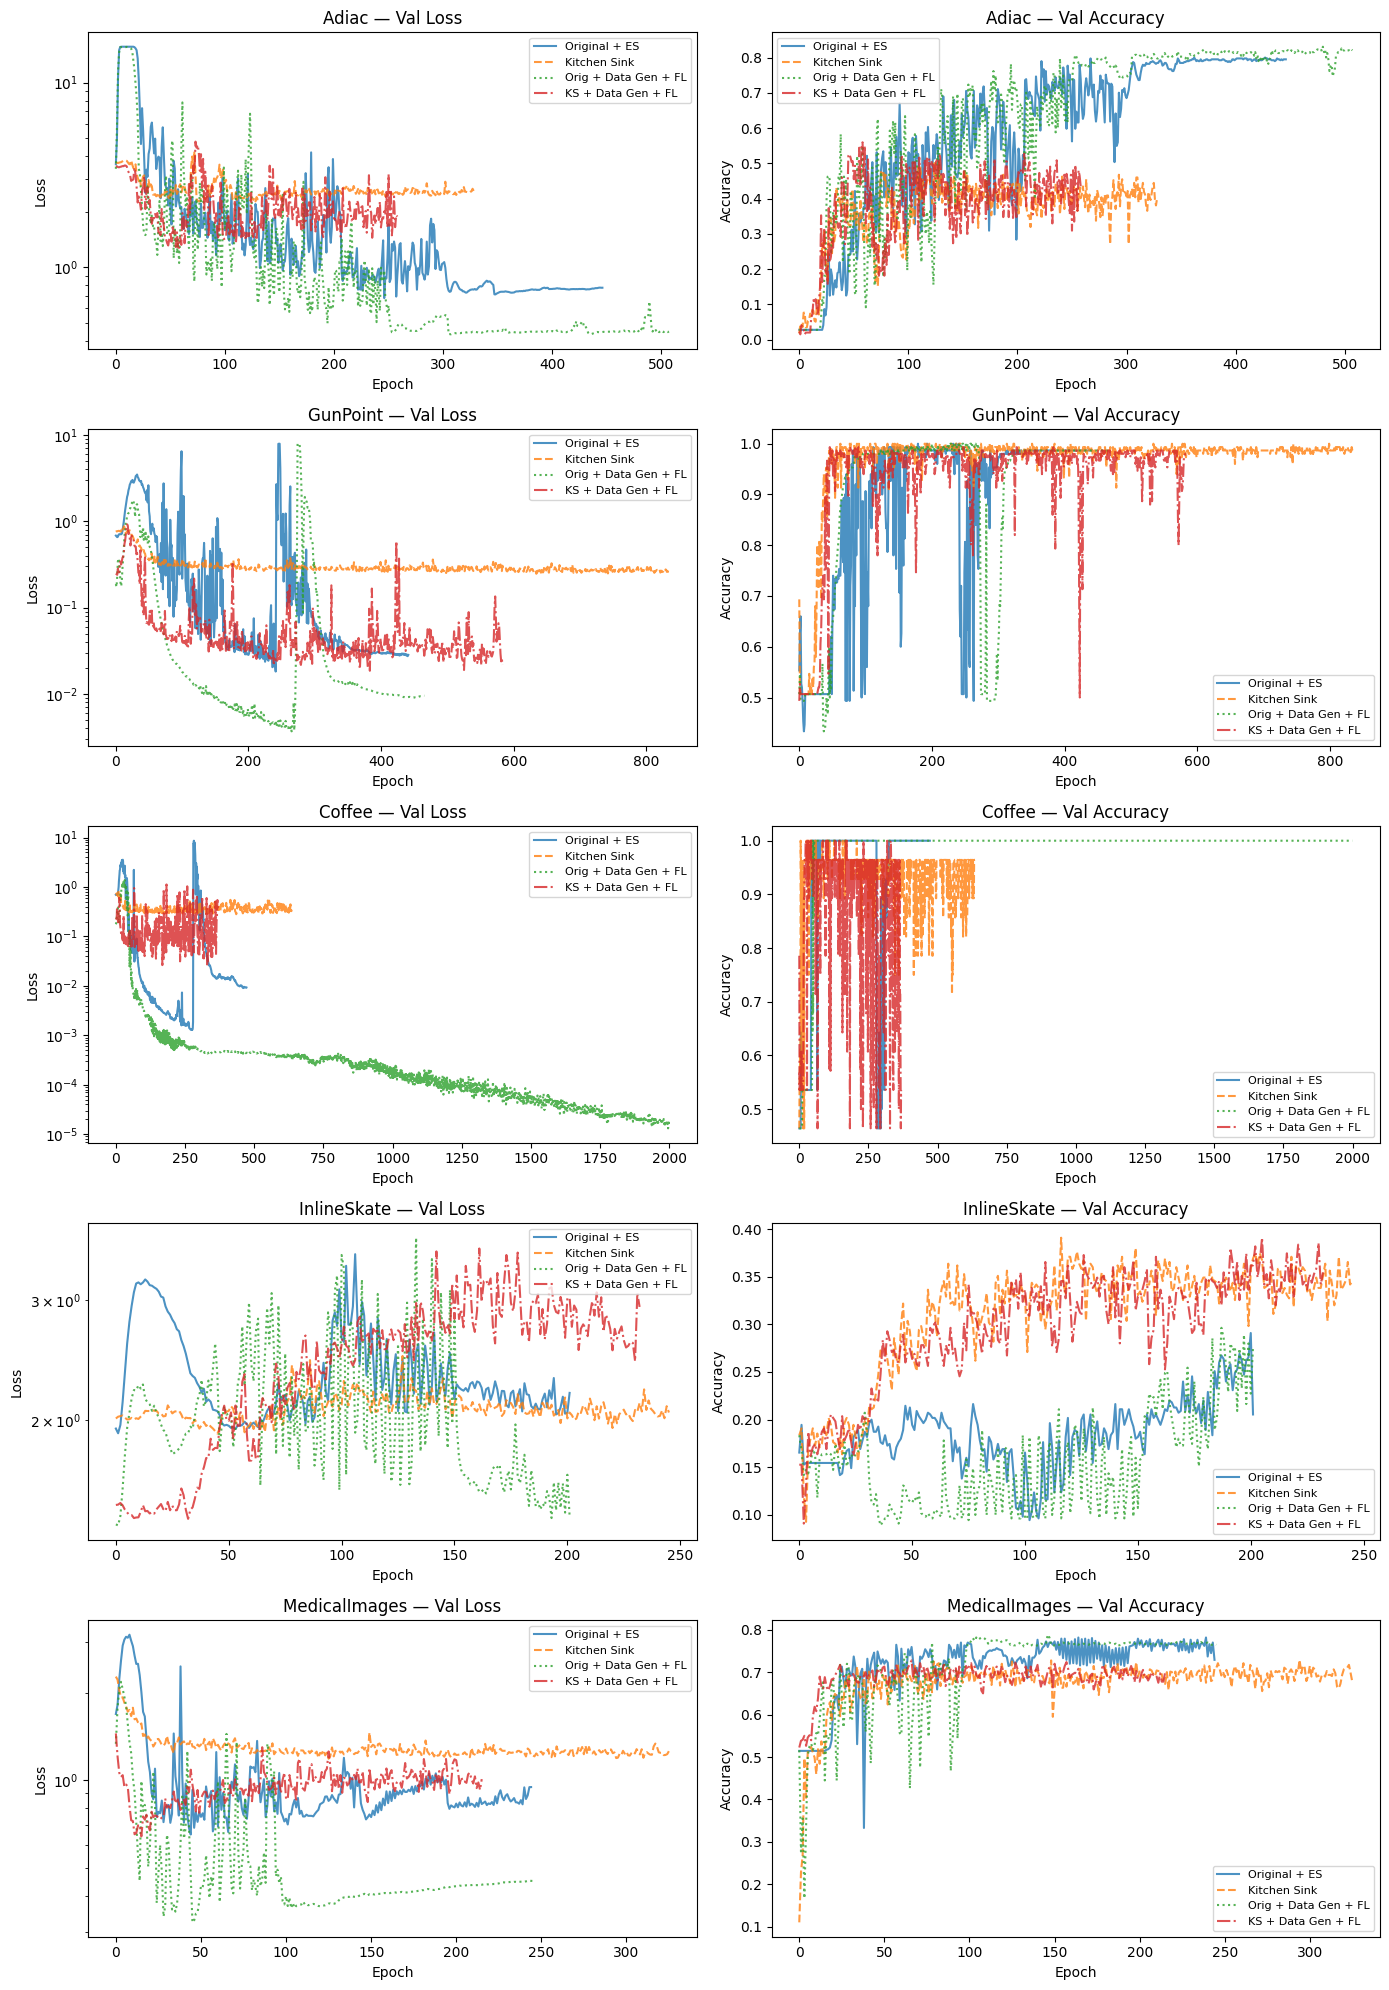

In [19]:
# Training curves — 4-experiment comparison (seed 0)
fig, axes = plt.subplots(len(CONFIG['datasets']), 2,
                         figsize=(14, 4 * len(CONFIG['datasets'])))
if len(CONFIG['datasets']) == 1:
    axes = axes.reshape(1, -1)

for row, ds in enumerate(CONFIG['datasets']):
    h_es = earlystop_results[ds]['all_results'][0]['history']
    h_ks = kitchen_sink_results[ds]['all_results'][0]['history']
    h_df = datagen_focal_results[ds]['all_results'][0]['history']
    h_kd = kitchen_sink_datagen_results[ds]['all_results'][0]['history']

    ax = axes[row, 0]
    ax.plot(h_es['val_loss'], label='Original + ES',       alpha=0.8)
    ax.plot(h_ks['val_loss'], label='Kitchen Sink',        alpha=0.8, ls='--')
    ax.plot(h_df['val_loss'], label='Orig + Data Gen + FL',alpha=0.8, ls=':')
    ax.plot(h_kd['val_loss'], label='KS + Data Gen + FL',  alpha=0.8, ls='-.')
    ax.set_title(f'{ds} — Val Loss'); ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss'); ax.set_yscale('log'); ax.legend(fontsize=8)

    ax = axes[row, 1]
    ax.plot(h_es['val_accuracy'], label='Original + ES',       alpha=0.8)
    ax.plot(h_ks['val_accuracy'], label='Kitchen Sink',        alpha=0.8, ls='--')
    ax.plot(h_df['val_accuracy'], label='Orig + Data Gen + FL',alpha=0.8, ls=':')
    ax.plot(h_kd['val_accuracy'], label='KS + Data Gen + FL',  alpha=0.8, ls='-.')
    ax.set_title(f'{ds} — Val Accuracy'); ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'fcn_training_curves.png'), dpi=150)
plt.show()


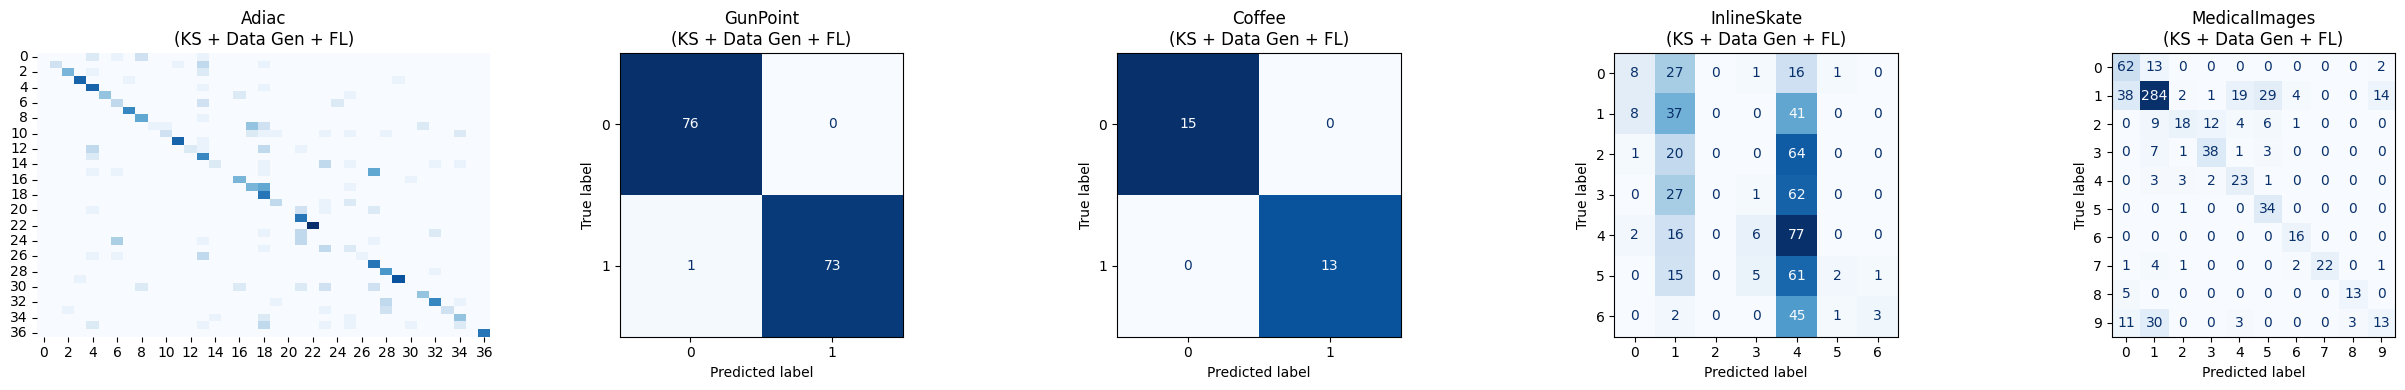

In [20]:
# Confusion matrices (Kitchen Sink + Data Gen + FL, seed 0)
n_ds = len(CONFIG['datasets'])
fig, axes = plt.subplots(1, n_ds, figsize=(5 * n_ds, 4))
if n_ds == 1: axes = [axes]
for i, ds in enumerate(CONFIG['datasets']):
    best_run = kitchen_sink_datagen_results[ds]['all_results'][0]
    cm = confusion_matrix(best_run['y_test'], best_run['y_pred'])
    nb_classes = data_store[ds]['nb_classes']
    if nb_classes > 10:
        sns.heatmap(cm, ax=axes[i], cmap='Blues', cbar=False)
    else:
        ConfusionMatrixDisplay(cm).plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{ds}\n(KS + Data Gen + FL)')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'fcn_confusion_matrices.png'), dpi=150)
plt.show()


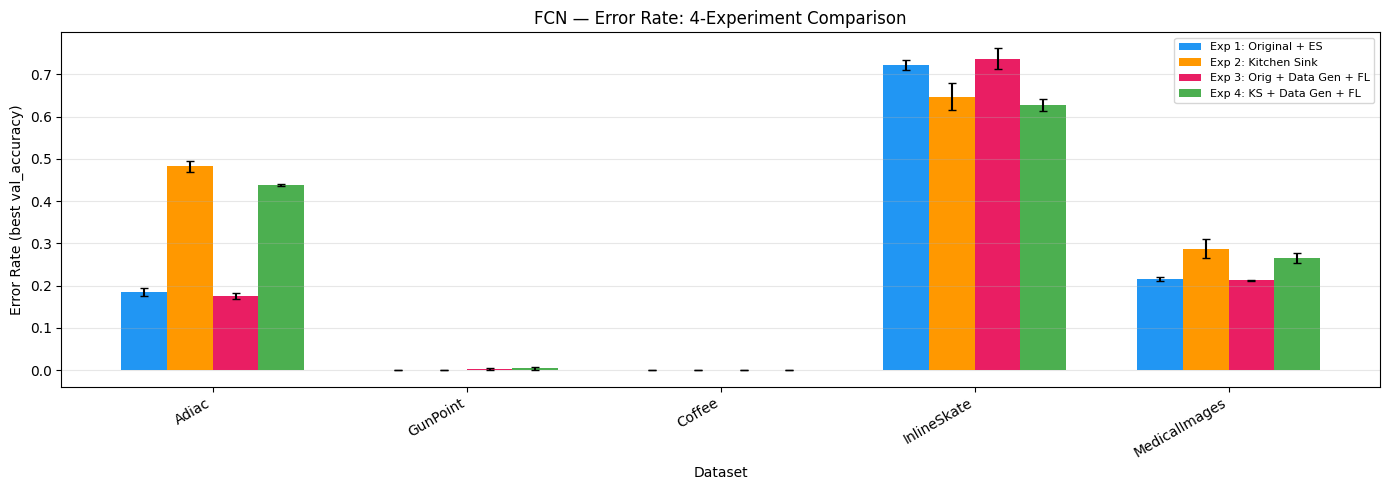

In [21]:
# Bar chart: 4-experiment comparison
datasets = CONFIG['datasets']
x_pos = np.arange(len(datasets))
width = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]
labels  = ['Exp 1: Original + ES', 'Exp 2: Kitchen Sink',
           'Exp 3: Orig + Data Gen + FL', 'Exp 4: KS + Data Gen + FL']
colours = ['#2196F3', '#FF9800', '#E91E63', '#4CAF50']
errors_list = [
    [earlystop_results[ds]['mean_best_val_error']            for ds in datasets],
    [kitchen_sink_results[ds]['mean_best_val_error']         for ds in datasets],
    [datagen_focal_results[ds]['mean_best_val_error']        for ds in datasets],
    [kitchen_sink_datagen_results[ds]['mean_best_val_error'] for ds in datasets],
]
yerrs_list = [
    [earlystop_results[ds]['std_best_val_error']             for ds in datasets],
    [kitchen_sink_results[ds]['std_best_val_error']          for ds in datasets],
    [datagen_focal_results[ds]['std_best_val_error']         for ds in datasets],
    [kitchen_sink_datagen_results[ds]['std_best_val_error']  for ds in datasets],
]

fig, ax = plt.subplots(figsize=(14, 5))
for i, (label, colour, errs, yerrs) in enumerate(zip(labels, colours, errors_list, yerrs_list)):
    ax.bar(x_pos + offsets[i] * width, errs, width,
           label=label, color=colour, yerr=yerrs, capsize=3)

ax.set_xlabel('Dataset'); ax.set_ylabel('Error Rate (best val_accuracy)')
ax.set_title('FCN — Error Rate: 4-Experiment Comparison')
ax.set_xticks(x_pos); ax.set_xticklabels(datasets, rotation=30, ha='right')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'fcn_barchart.png'), dpi=150)
plt.show()


### Class Activation Maps (CAM)

**IMPROVEMENT:** The original CAM code uses deprecated `K.learning_phase()`.
We rewrite using a proper Keras submodel to extract the last conv layer's
output, then compute CAMs as described in the paper (Section IV).

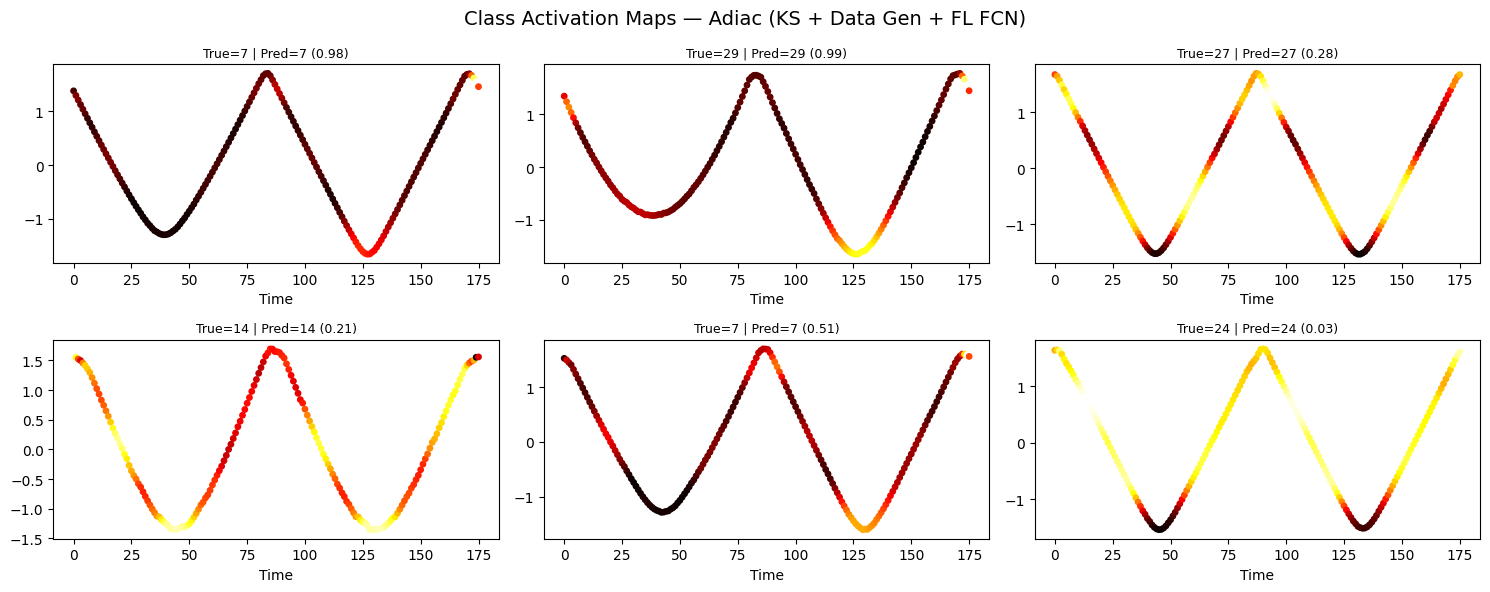

E0000 00:00:1775805652.540699    8317 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


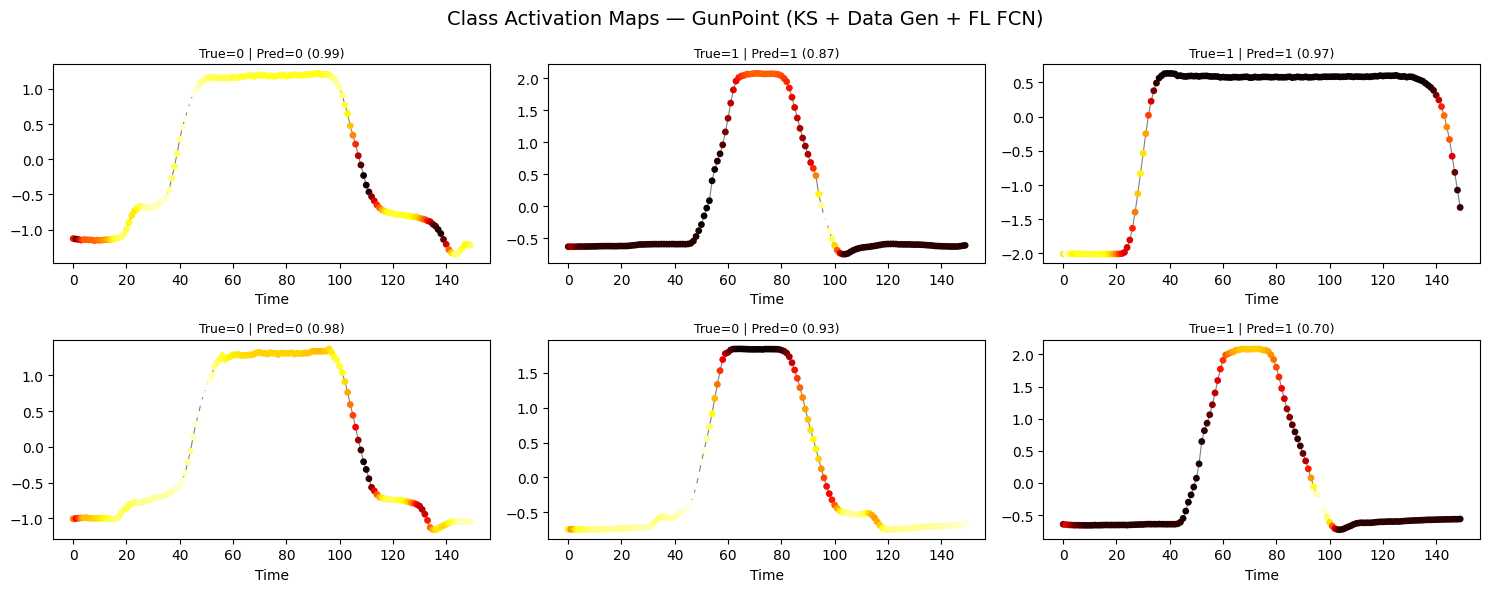

In [22]:
# Modern CAM implementation

# CAM for class c at temporal location t:
#   M_c(t) = sum_k( w_c_k * S_k(t) )
# where S_k(t) is the activation of filter k at time t in the last conv layer, and w_c_k is the softmax weight for
# class c from filter k.


def compute_cam(model, x_sample, true_label=None):
    """Compute Class Activation Map for a single sample."""
    # Find last conv/activation layer before GAP
    last_conv_layer = None
    for layer in reversed(model.layers):
        if isinstance(layer, (layers.Conv1D, layers.Activation)):
            if len(layer.output.shape) == 3:  # (batch, time, channels)
                last_conv_layer = layer
                break

    if last_conv_layer is None:
        print("Could not find last conv layer for CAM")
        return None

    # Build submodel to get last conv output
    cam_model = keras.Model(inputs=model.input,
                            outputs=[last_conv_layer.output, model.output])

    # Get activations and predictions
    x_in = x_sample.reshape(1, -1, 1) if x_sample.ndim == 1 else x_sample
    if x_in.ndim == 2:
        x_in = x_in.reshape(x_in.shape[0], x_in.shape[1], 1)
    conv_out, pred = cam_model.predict(x_in, verbose=0)

    # Get softmax weights (last dense layer)
    softmax_weights = model.layers[-1].get_weights()[0]  # (features, classes)

    # Predicted or specified class
    if true_label is not None:
        class_idx = int(true_label)
    else:
        class_idx = int(np.argmax(pred[0]))

    # Compute CAM
    # conv_out shape: (1, T_conv, n_filters)
    # We need weights for the target class
    if softmax_weights.shape[0] == conv_out.shape[-1]:
        # Direct: GAP only
        w = softmax_weights[:, class_idx]
        cam = np.dot(conv_out[0], w)
    else:
        # GAP+GMP concat: first half of weights for GAP features
        n_filters = conv_out.shape[-1]
        w = softmax_weights[:n_filters, class_idx]
        cam = np.dot(conv_out[0], w)

    # Normalise to [0, 1]
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    # Upsample if conv output is different length than input
    if len(cam) != x_sample.shape[0] if x_sample.ndim == 1 else x_sample.shape[1]:
        target_len = x_sample.shape[0] if x_sample.ndim == 1 else x_sample.shape[1]
        cam = np.interp(np.linspace(0, len(cam)-1, target_len),
                        np.arange(len(cam)), cam)
    return cam, class_idx, float(pred[0][class_idx])


# Plot CAMs for a few test samples per dataset
for ds in ['Adiac', 'GunPoint']:
    if ds not in data_store:
        continue
    model = kitchen_sink_datagen_results[ds]['all_results'][0]['model']
    x_te = data_store[ds]['x_test']
    y_te = data_store[ds]['y_test']

    fig, axes = plt.subplots(2, 3, figsize=(15, 6))
    fig.suptitle(f'Class Activation Maps \u2014 {ds} (KS + Data Gen + FL FCN)', fontsize=14)

    for i in range(min(6, len(x_te))):
        ax = axes[i // 3, i % 3]
        result = compute_cam(model, x_te[i], true_label=y_te[i])
        if result is None:
            continue
        cam, cls_idx, prob = result
        ts = x_te[i].squeeze()

        ax.plot(ts, color='black', alpha=0.5, linewidth=0.8)
        ax.scatter(range(len(ts)), ts, c=cam, cmap='hot_r', s=15, zorder=5)
        ax.set_title(f'True={y_te[i]} | Pred={cls_idx} ({prob:.2f})', fontsize=9)
        ax.set_xlabel('Time')

    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['output_dir'], f'fcn_cam_{ds}.png'), dpi=150)
    plt.show()

### Per-Class Metrics, MPCE & Save Results

In [23]:
# Classification reports (Kitchen Sink + Data Gen + FL, seed 0)
for ds in CONFIG['datasets']:
    best_run = kitchen_sink_datagen_results[ds]['all_results'][0]
    print(f"\n{'='*60}")
    print(f"  Classification Report: {ds} (KS + Data Gen + FL FCN)")
    print(f"{'='*60}")
    print(classification_report(best_run['y_test'], best_run['y_pred'],
                                digits=3, zero_division=0))



  Classification Report: Adiac (KS + Data Gen + FL FCN)
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         7
           1      1.000     0.333     0.500         9
           2      0.875     0.700     0.778        10
           3      0.923     0.857     0.889        14
           4      0.462     0.857     0.600        14
           5      1.000     0.667     0.800         9
           6      0.333     0.444     0.381         9
           7      0.909     1.000     0.952        10
           8      0.615     0.889     0.727         9
           9      1.000     0.077     0.143        13
          10      0.750     0.250     0.375        12
          11      0.923     0.923     0.923        13
          12      1.000     0.167     0.286        12
          13      0.333     0.833     0.476        12
          14      0.667     0.200     0.308        10
          15      0.000     0.000     0.000        11
          16      0.636 

In [24]:
# MPCE
def compute_mpce(results_dict, key='mean_error'):
    return np.mean([results_dict[ds][key] / data_store[ds]['nb_classes']
                    for ds in CONFIG['datasets']])

mpce_paper = np.mean([PAPER_FCN_ERRORS[ds] / data_store[ds]['nb_classes']
                      for ds in CONFIG['datasets']])
print("Mean Per-Class Error (MPCE) — lower is better\n")
print(f"  Paper FCN (published)     : {mpce_paper:.5f}")
for vn in [k for k in all_experiments if k != 'Paper']:
    mr = compute_mpce(all_experiments[vn], 'mean_error')
    mb = compute_mpce(all_experiments[vn], 'mean_best_val_error')
    print(f"  {vn:25s}: {mr:.5f} (restored)  {mb:.5f} (best val_acc)")

Mean Per-Class Error (MPCE) — lower is better

  Paper FCN (published)     : 0.02176
  Original + ES            : 0.03000 (restored)  0.02594 (best val_acc)
  Kitchen Sink             : 0.03205 (restored)  0.02685 (best val_acc)
  Original + Data Gen + FL : 0.03043 (restored)  0.02648 (best val_acc)
  KS + Data Gen + FL       : 0.03310 (restored)  0.02605 (best val_acc)


In [25]:
# Save results
rows = []
for ds in CONFIG['datasets']:
    row = {'Dataset': ds, 'Classes': data_store[ds]['nb_classes'],
           'Train_N': data_store[ds]['x_train'].shape[0],
           'Test_N': data_store[ds]['x_test'].shape[0],
           'Length': data_store[ds]['x_train'].shape[1],
           'Paper_Error': PAPER_FCN_ERRORS.get(ds, None)}
    for en, ed in all_experiments.items():
        if en == 'Paper': continue
        safe = en.replace('+', '').replace(' ', '_').strip('_')
        row[f'{safe}_Error'] = ed[ds]['mean_error']
        row[f'{safe}_Std'] = ed[ds]['std_error']
        row[f'{safe}_BestValErr'] = ed[ds]['mean_best_val_error']
    rows.append(row)
df = pd.DataFrame(rows)
csv_path = os.path.join(CONFIG['output_dir'], 'fcn_3_0_results.csv')
df.to_csv(csv_path, index=False)
print(f"Results saved to {csv_path}\n")
df_d = df.copy()
df_d[df_d.select_dtypes('float').columns] = df_d.select_dtypes('float').round(4)
print(df_d.set_index('Dataset').T.to_string())

Results saved to results_3_0/fcn_3_0_results.csv

Dataset                               Adiac  GunPoint    Coffee  InlineSkate  MedicalImages
Classes                             37.0000    2.0000    2.0000       7.0000        10.0000
Train_N                            390.0000   50.0000   28.0000     100.0000       381.0000
Test_N                             391.0000  150.0000   28.0000     550.0000       760.0000
Length                             176.0000  150.0000  286.0000    1882.0000        99.0000
Paper_Error                          0.1430    0.0000    0.0000       0.5890         0.2080
Original__ES_Error                   0.1995    0.0022    0.0000       0.8297         0.2496
Original__ES_Std                     0.0188    0.0031    0.0000       0.0174         0.0102
Original__ES_BestValErr              0.1850    0.0000    0.0000       0.7218         0.2158
Kitchen_Sink_Error                   0.5090    0.0133    0.0119       0.7315         0.2939
Kitchen_Sink_Std              

In [ ]:
# Save to Google Drive
from google.colab import drive
drive.mount('/content/drive')
import shutil, pickle

drive_dir = '/content/drive/MyDrive/TSC_Results/FCN_3_0'
os.makedirs(drive_dir, exist_ok=True)

for fname in os.listdir(CONFIG['output_dir']):
    shutil.copy2(os.path.join(CONFIG['output_dir'], fname),
                 os.path.join(drive_dir, fname))
    print(f"  → {drive_dir}/{fname}")

save_data = {k: v for k, v in all_experiments.items()}
save_data['CONFIG'] = CONFIG
save_data['PAPER_FCN_ERRORS'] = PAPER_FCN_ERRORS
with open(os.path.join(drive_dir, 'fcn_3_0_all_results.pkl'), 'wb') as f:
    pickle.dump(save_data, f)
print(f"\nAll saved to {drive_dir}")

from google.colab import files
shutil.make_archive('/content/fcn_3_0_results', 'zip', CONFIG['output_dir'])
files.download('/content/fcn_3_0_results.zip')

### Summary of Findings (3.0 — 2× Width)

#### Architecture Improvements
- **Squeeze-and-Excitation attention** — lightweight channel attention that helps
  the FCN focus on discriminative feature maps. Particularly valuable for Adiac
  (37 classes with subtle inter-class differences) where the model needs to learn
  which spectral features distinguish closely related patterns.
- **Multi-scale parallel convolutions** — captures patterns at multiple temporal
  scales simultaneously. InlineSkate (1882 timesteps) benefits from both large
  kernels (global trends) and small kernels (local gestures). Inspired by
  InceptionTime but applied within the FCN framework.
- **GAP + GMP concatenation** — Global Average Pooling captures the mean activation
  across time, while Global Max Pooling captures the peak response. Concatenating
  both gives the softmax classifier richer information about each feature map's
  behaviour.
- **Deep 5-block variant** — additional capacity with residual skip connections.
  Skip connections allow the deeper model to degrade gracefully to the 3-block
  version when extra depth isn't needed (Coffee, GunPoint).

#### Regularisation
- **SpatialDropout1D** — drops entire feature map channels, more appropriate for
  conv layers than element-wise dropout. The original FCN has zero regularisation.
- **L2 weight regularisation** — continuous weight decay on conv kernels.
- **Label smoothing** — reduces overconfident predictions, especially on very small
  training sets (Coffee: 28 samples).
- **Gradient clipping** — prevents gradient explosion on long sequences (InlineSkate).

#### Preprocessing
- **Class weighting** — essential for MedicalImages (6 vs 203 samples per class).
- **Jitter + scaling** — input-space noise for regularisation.
- **Window warping** — randomly speeds up/slows down subsequences, teaching temporal
  invariance. Particularly relevant for InlineSkate where gesture execution speed
  varies between subjects.
- **Mixup** — creates virtual training samples via interpolation between pairs.

#### CAM Visualisation
- Rewritten using modern Keras submodels instead of deprecated `K.learning_phase()`.
- Supports both GAP-only and GAP+GMP architectures.